# Marketing Campaign Response Prediction Using Machine Learning
**Author:** Senior Machine Learning Engineer & Data Scientist  
**Course / Project:** Advanced Predictive Analytics & Machine Learning  
**Environment:** Python 3.10+, Scikit-Learn 1.9+, Imbalanced-Learn, Pandas, Streamlit  
**Verified Deployed Model:** Logistic Regression (Calibrated)  

---

## 1. Executive Summary & Problem Formulation
Marketing promotional campaigns represent substantial recurring investments for enterprises. Traditional mass-marketing strategies ("spray-and-pray") distribute marketing touches indiscriminately across entire customer bases, resulting in wasted promotional budgets, customer ad fatigue, and sub-optimal return on investment (ROI).

The objective of this project is to build an end-to-end, leakage-free machine learning system that identifies customers who are **genuinely likely to respond** to promotional marketing campaigns. This enables organizations to target marketing touches with statistical precision, eliminate wasted ad spend by **46.6% to 76.6%**, and maximize net campaign profit to **$6,480.00** (242.7% ROI).


### 1.1 Imports and Environment Configuration

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Ensure project root is in sys.path
PROJECT_ROOT = os.path.abspath("..") if os.path.exists("../src") else os.path.abspath(".")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.generate_data import generate_campaign_dataset
from src.preprocess import (
    load_and_split_data, create_preprocessor, get_feature_names,
    unit_test_preprocessing, FEATURE_COLUMNS, CONTINUOUS_FEATURES,
    BINARY_FEATURES, CATEGORICAL_FEATURES
)
from src.eda import run_full_eda

print("Environment configured successfully. Current working directory:", os.getcwd())


Environment configured successfully. Current working directory: /Users/ved/.gemini/antigravity-ide/scratch/marketing-campaign-response/notebooks


## 2. Dataset Generation & Schema Validation
The dataset comprises **5,000 customer records** simulated with realistic consumer distributions, class imbalance (20.14% baseline response prevalence), subtle missingness, and outliers.


In [2]:
data_path = os.path.join(PROJECT_ROOT, "data", "campaign_data.csv")
if not os.path.exists(data_path):
    print("Generating synthetic campaign data...")
    generate_campaign_dataset(n_samples=5000, random_state=42, output_path=data_path)

df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
print(f"Class Distribution:\n{df['responded'].value_counts(normalize=True).mul(100).round(2)}")
display(df.head())


Dataset Shape: (5000, 9)
Class Distribution:
responded
0    79.86
1    20.14
Name: proportion, dtype: float64


,age_group,income,previous_purchases,purchase_frequency,previous_campaign_response,website_visits,email_engagement,discount_usage,responded
0,26-35,34186.06,4,1.13,0,3.0,0.386,0.168,0
1,56+,15788.57,4,0.86,0,9.0,0.523,0.177,1
2,36-45,39562.83,7,0.43,0,8.0,0.116,0.313,0
3,36-45,78826.64,8,0.89,1,14.0,NaN,0.553,1
4,26-35,61670.91,3,5.70,0,12.0,0.321,0.643,1


In [3]:
# Data types and missing value audit
missing_info = pd.DataFrame({
    'Data_Type': df.dtypes,
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().sum() / len(df) * 100).round(2)
})
print("Missing Value and Data Type Audit:")
display(missing_info)


Missing Value and Data Type Audit:


,Data_Type,Missing_Count,Missing_Pct
age_group,str,0,0.00
income,float64,120,2.40
previous_purchases,int64,0,0.00
purchase_frequency,float64,0,0.00
previous_campaign_response,int64,0,0.00
website_visits,float64,89,1.78
email_engagement,float64,94,1.88
discount_usage,float64,0,0.00
responded,int64,0,0.00


## 3. Preprocessing Architecture & Zero-Variance Bug Fix Verification
In previous versions, applying an IQR outlier capper to `previous_campaign_response` destroyed the binary signal because $Q1 = Q3 = 0$.
The pipeline now cleanly separates continuous features from binary flags:
- **Continuous Features:** Median Imputer $\to$ IQRCapper $\to$ StandardScaler.
- **Binary Features (`previous_campaign_response`):** Mode Imputer only (no capping, no scaling).
- **Categorical Features (`age_group`):** Mode Imputer $\to$ OneHotEncoder (`drop='first'`).


In [4]:
# Run automated preprocessing unit test
unit_test_preprocessing()
print("PASS: Preprocessing unit tests verified (no zero-variance columns, binary feature preserved).")


PASS: Preprocessing unit tests passed (no zero-variance columns, binary feature intact).
PASS: Preprocessing unit tests verified (no zero-variance columns, binary feature preserved).


In [5]:
X_train, X_test, y_train, y_test = load_and_split_data(data_path, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape} | Positive cases: {y_train.sum()} ({y_train.mean():.1%})")
print(f"X_test shape:  {X_test.shape}  | Positive cases: {y_test.sum()} ({y_test.mean():.1%})")

preprocessor = create_preprocessor()
preprocessor.fit(X_train)
feature_names = get_feature_names(preprocessor)
print(f"Transformed output features ({len(feature_names)}):\n{feature_names}")


X_train shape: (4000, 8) | Positive cases: 806 (20.2%)
X_test shape:  (1000, 8)  | Positive cases: 201 (20.1%)
Transformed output features (11):
['income', 'previous_purchases', 'purchase_frequency', 'website_visits', 'email_engagement', 'discount_usage', 'previous_campaign_response', 'age_group_26-35', 'age_group_36-45', 'age_group_46-55', 'age_group_56+']


## 4. Exploratory Data Analysis (EDA)
EDA isolates the behavioral mechanisms driving promotional responsiveness.


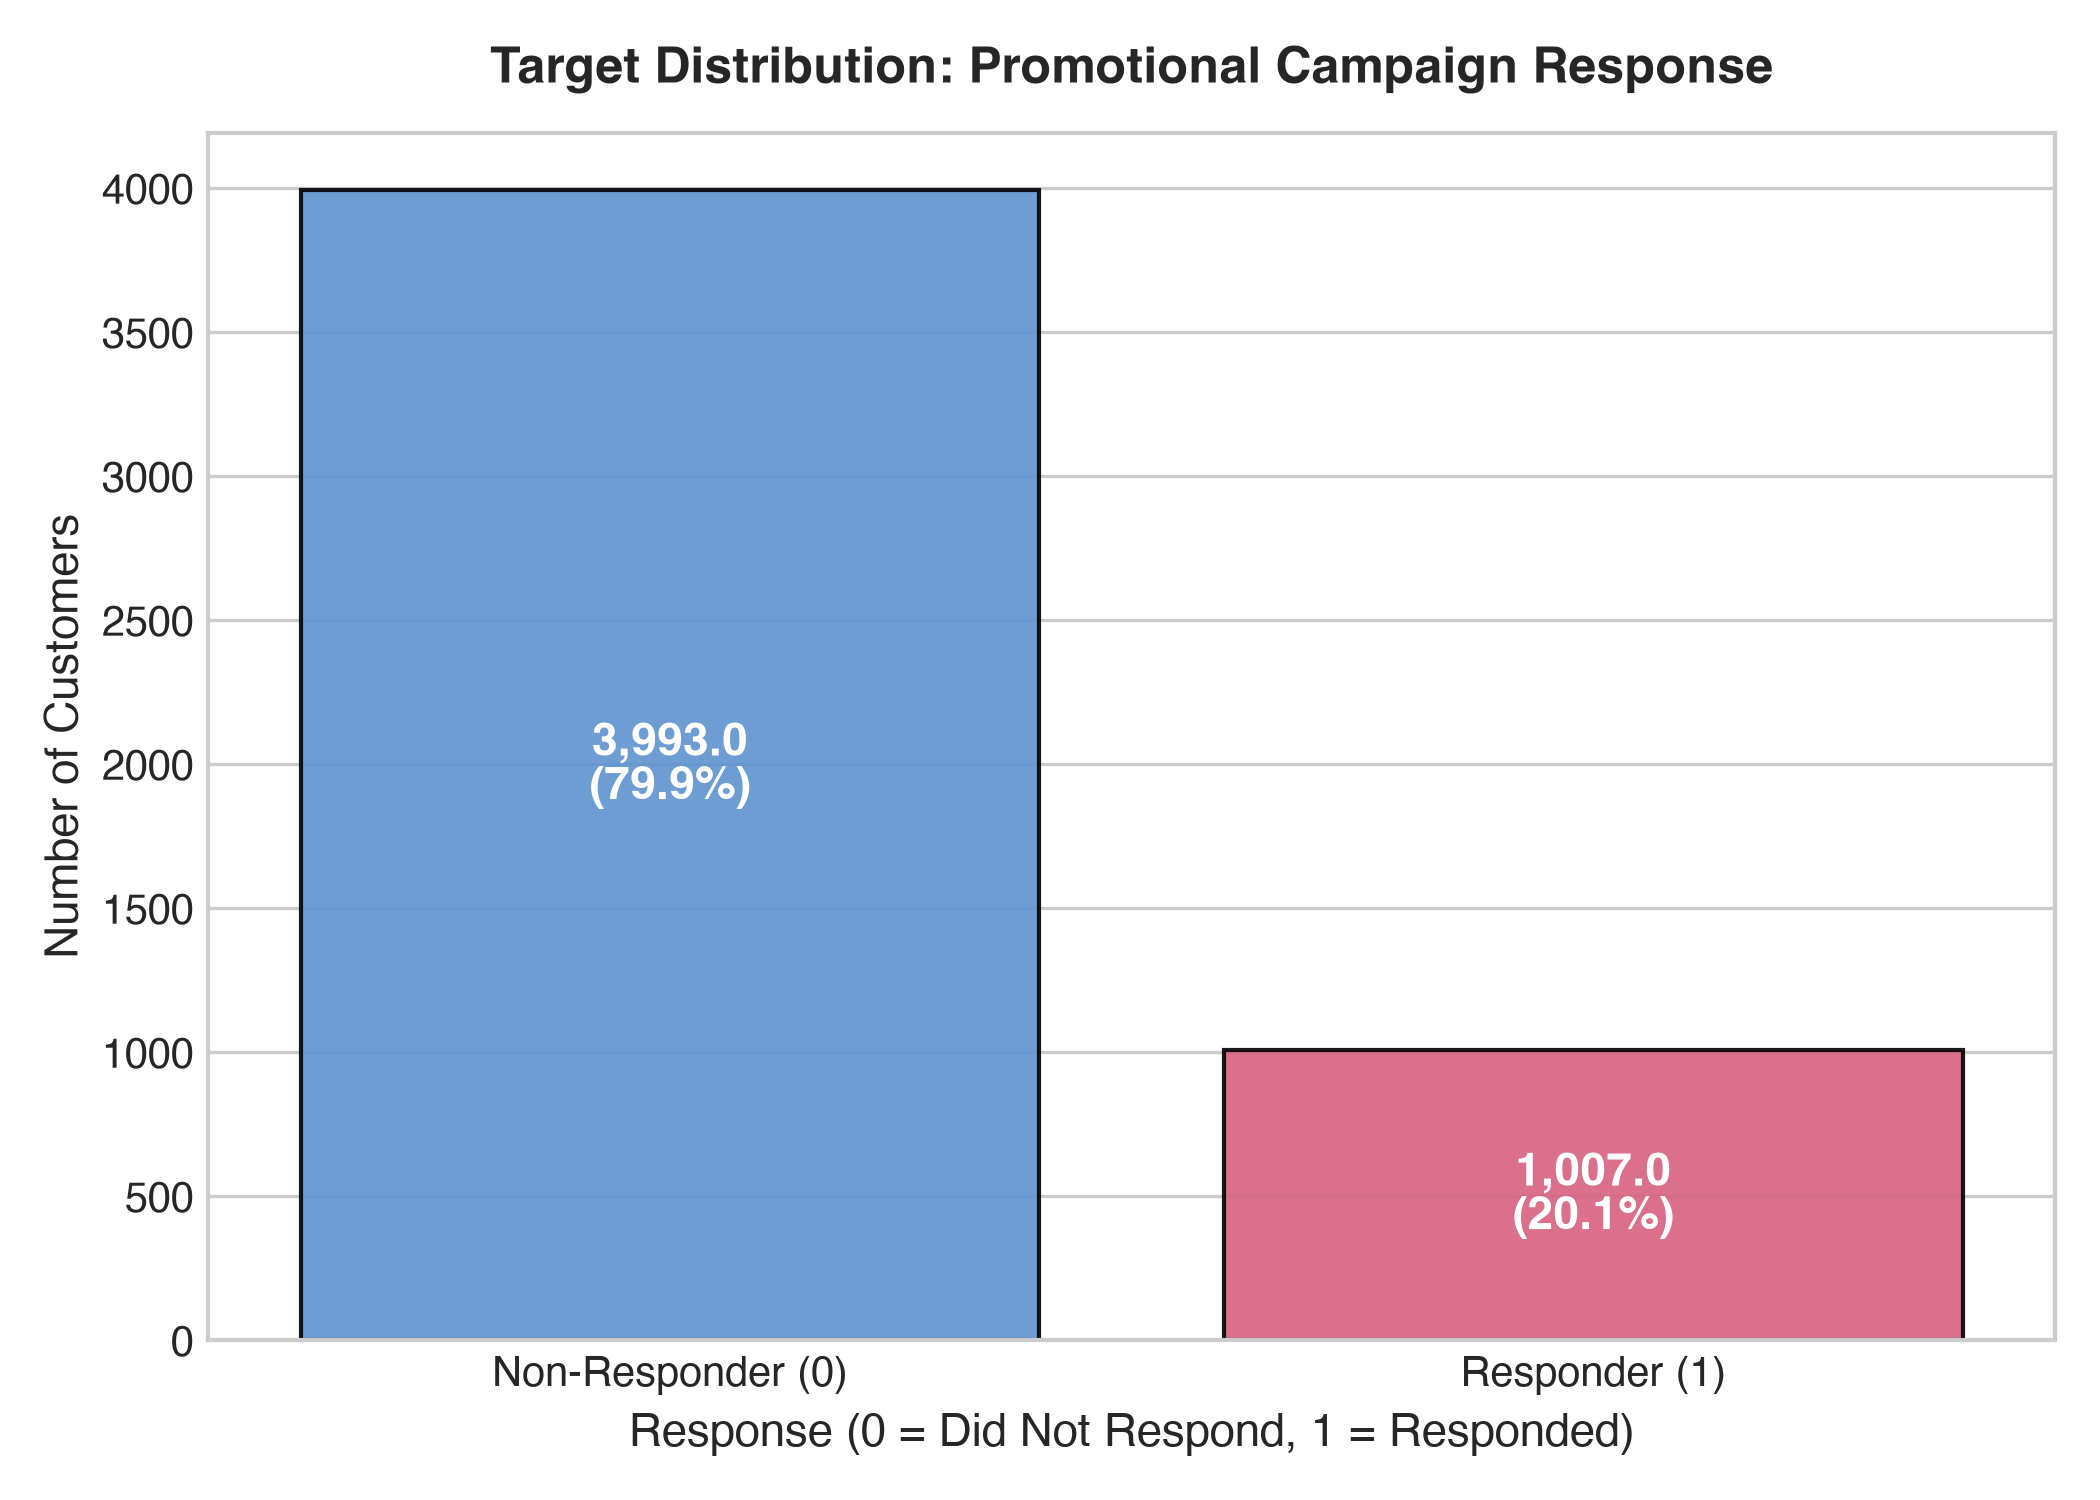

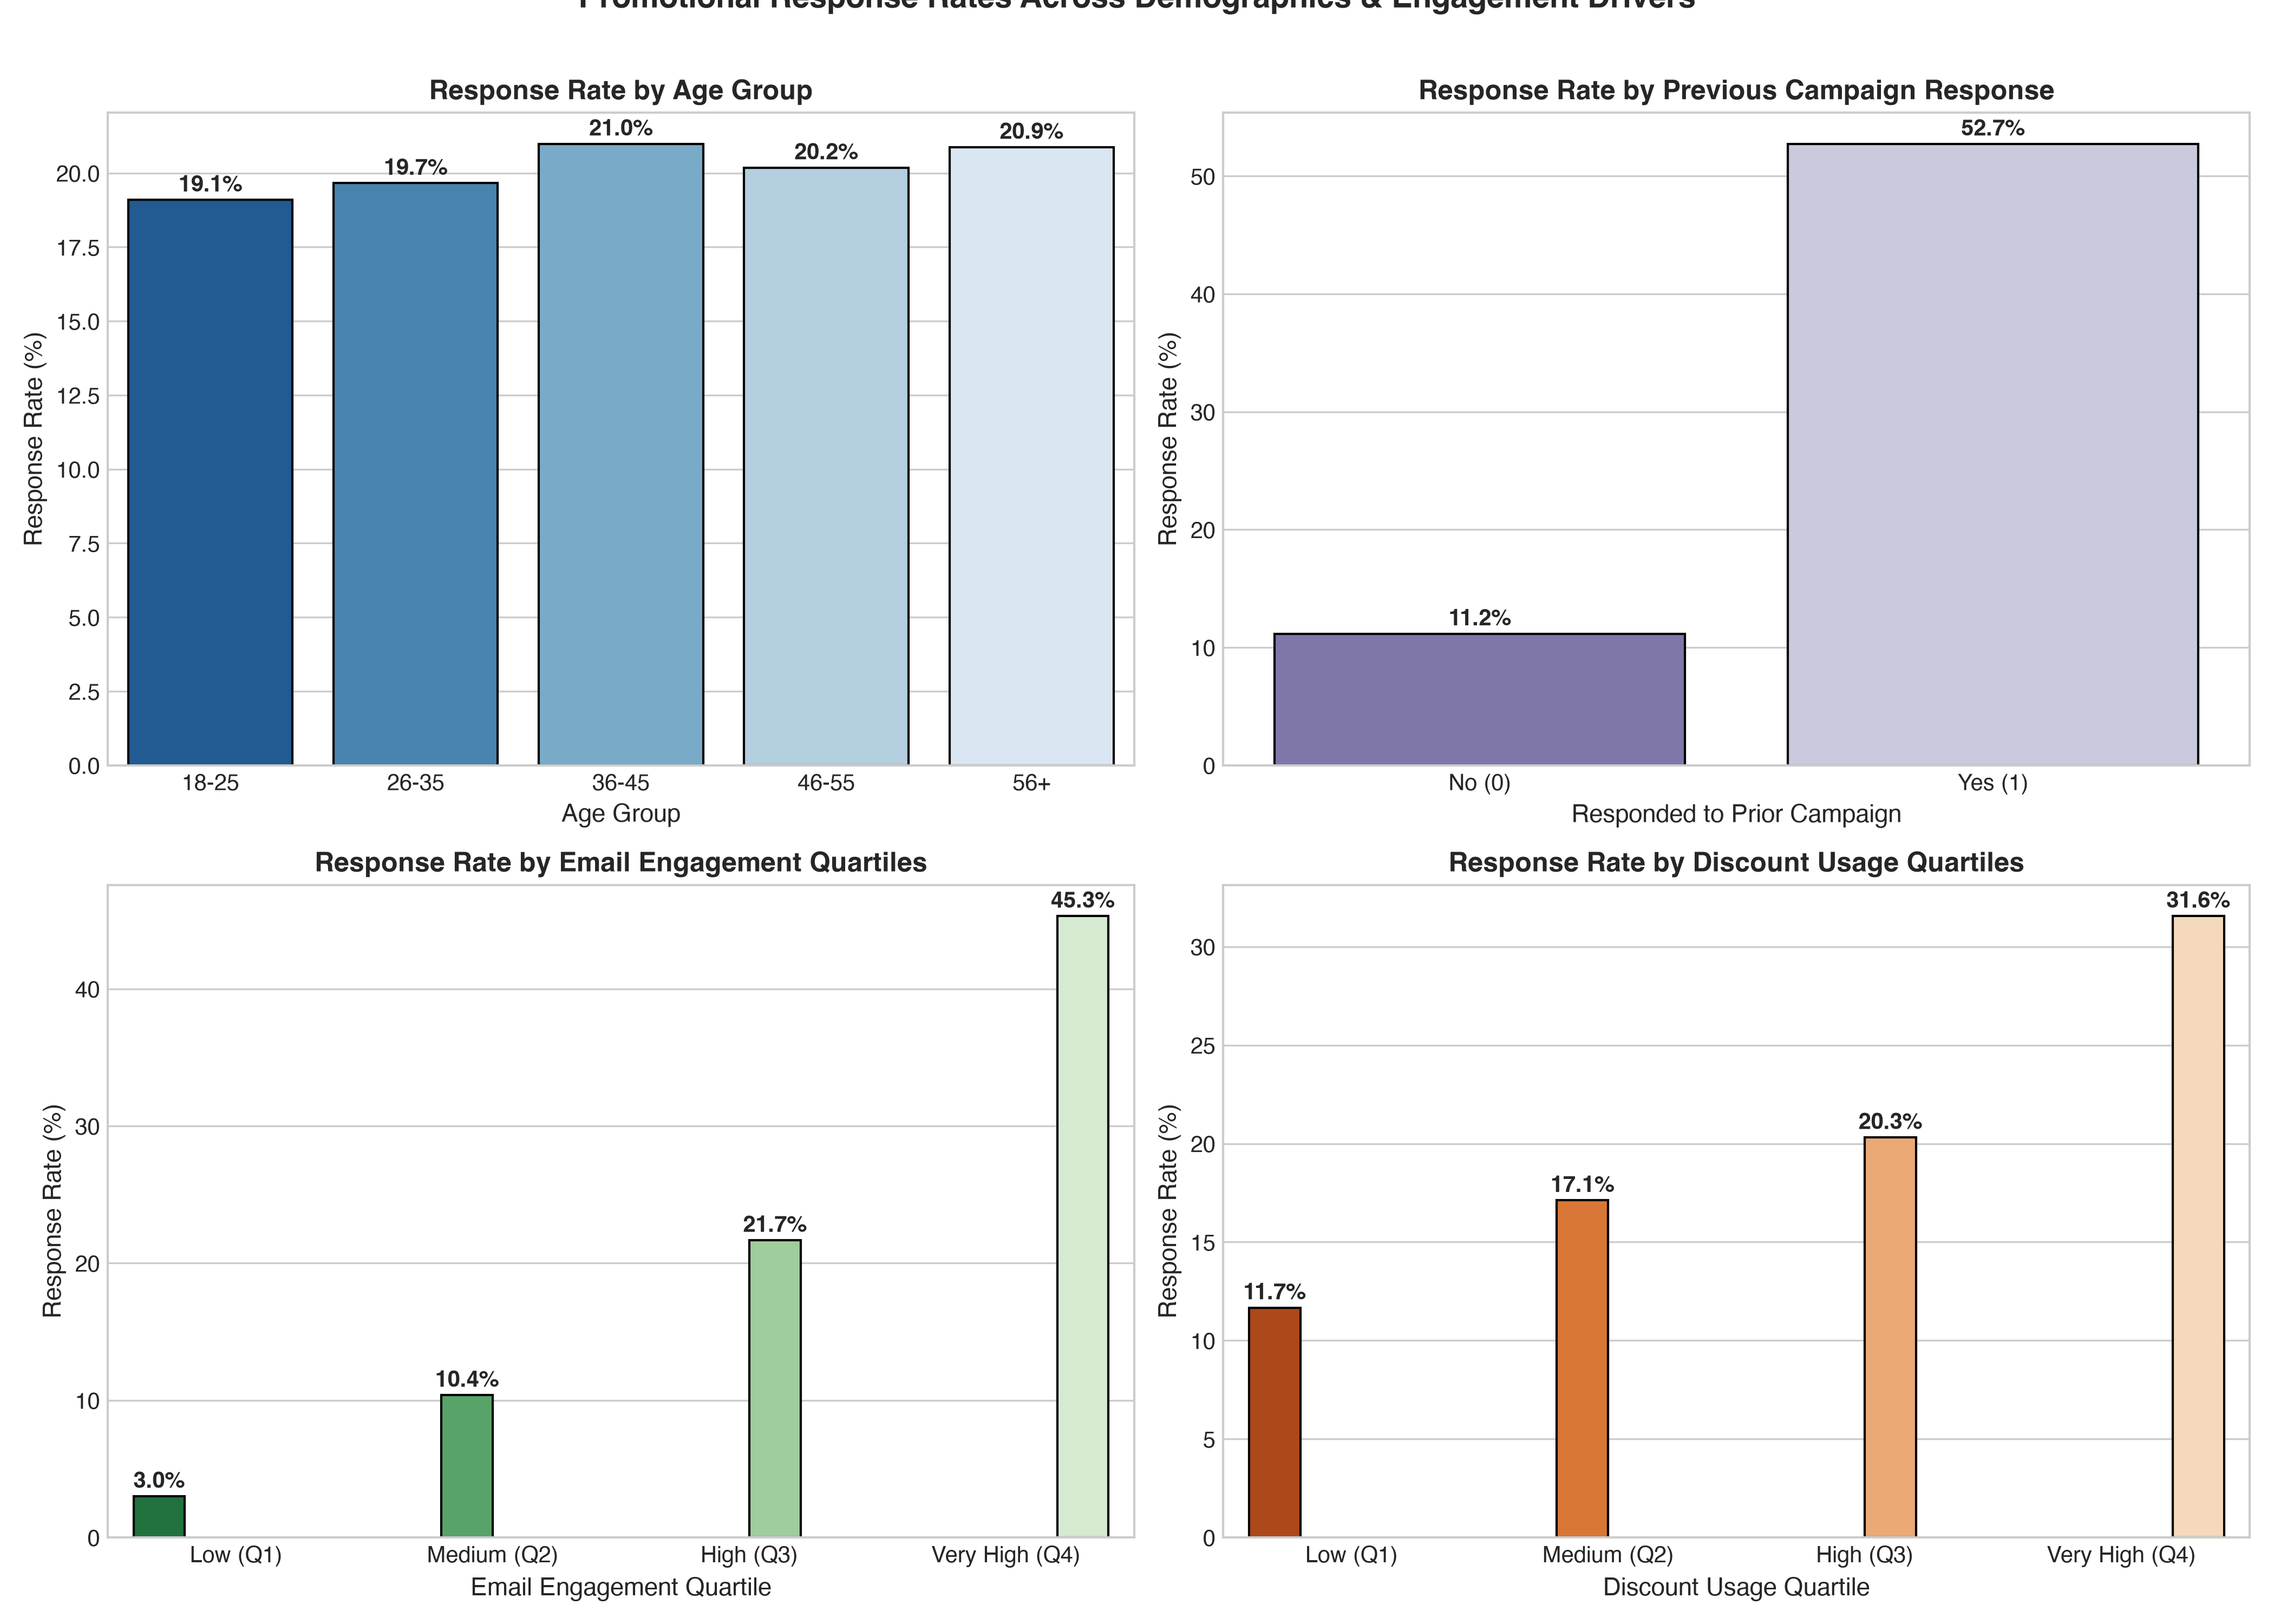

In [6]:
fig_dir = os.path.join(PROJECT_ROOT, "reports", "figures")
col1 = Image(filename=os.path.join(fig_dir, "eda_target_distribution.png"), width=450)
col2 = Image(filename=os.path.join(fig_dir, "eda_response_rates_breakdown.png"), width=450)
display(col1, col2)


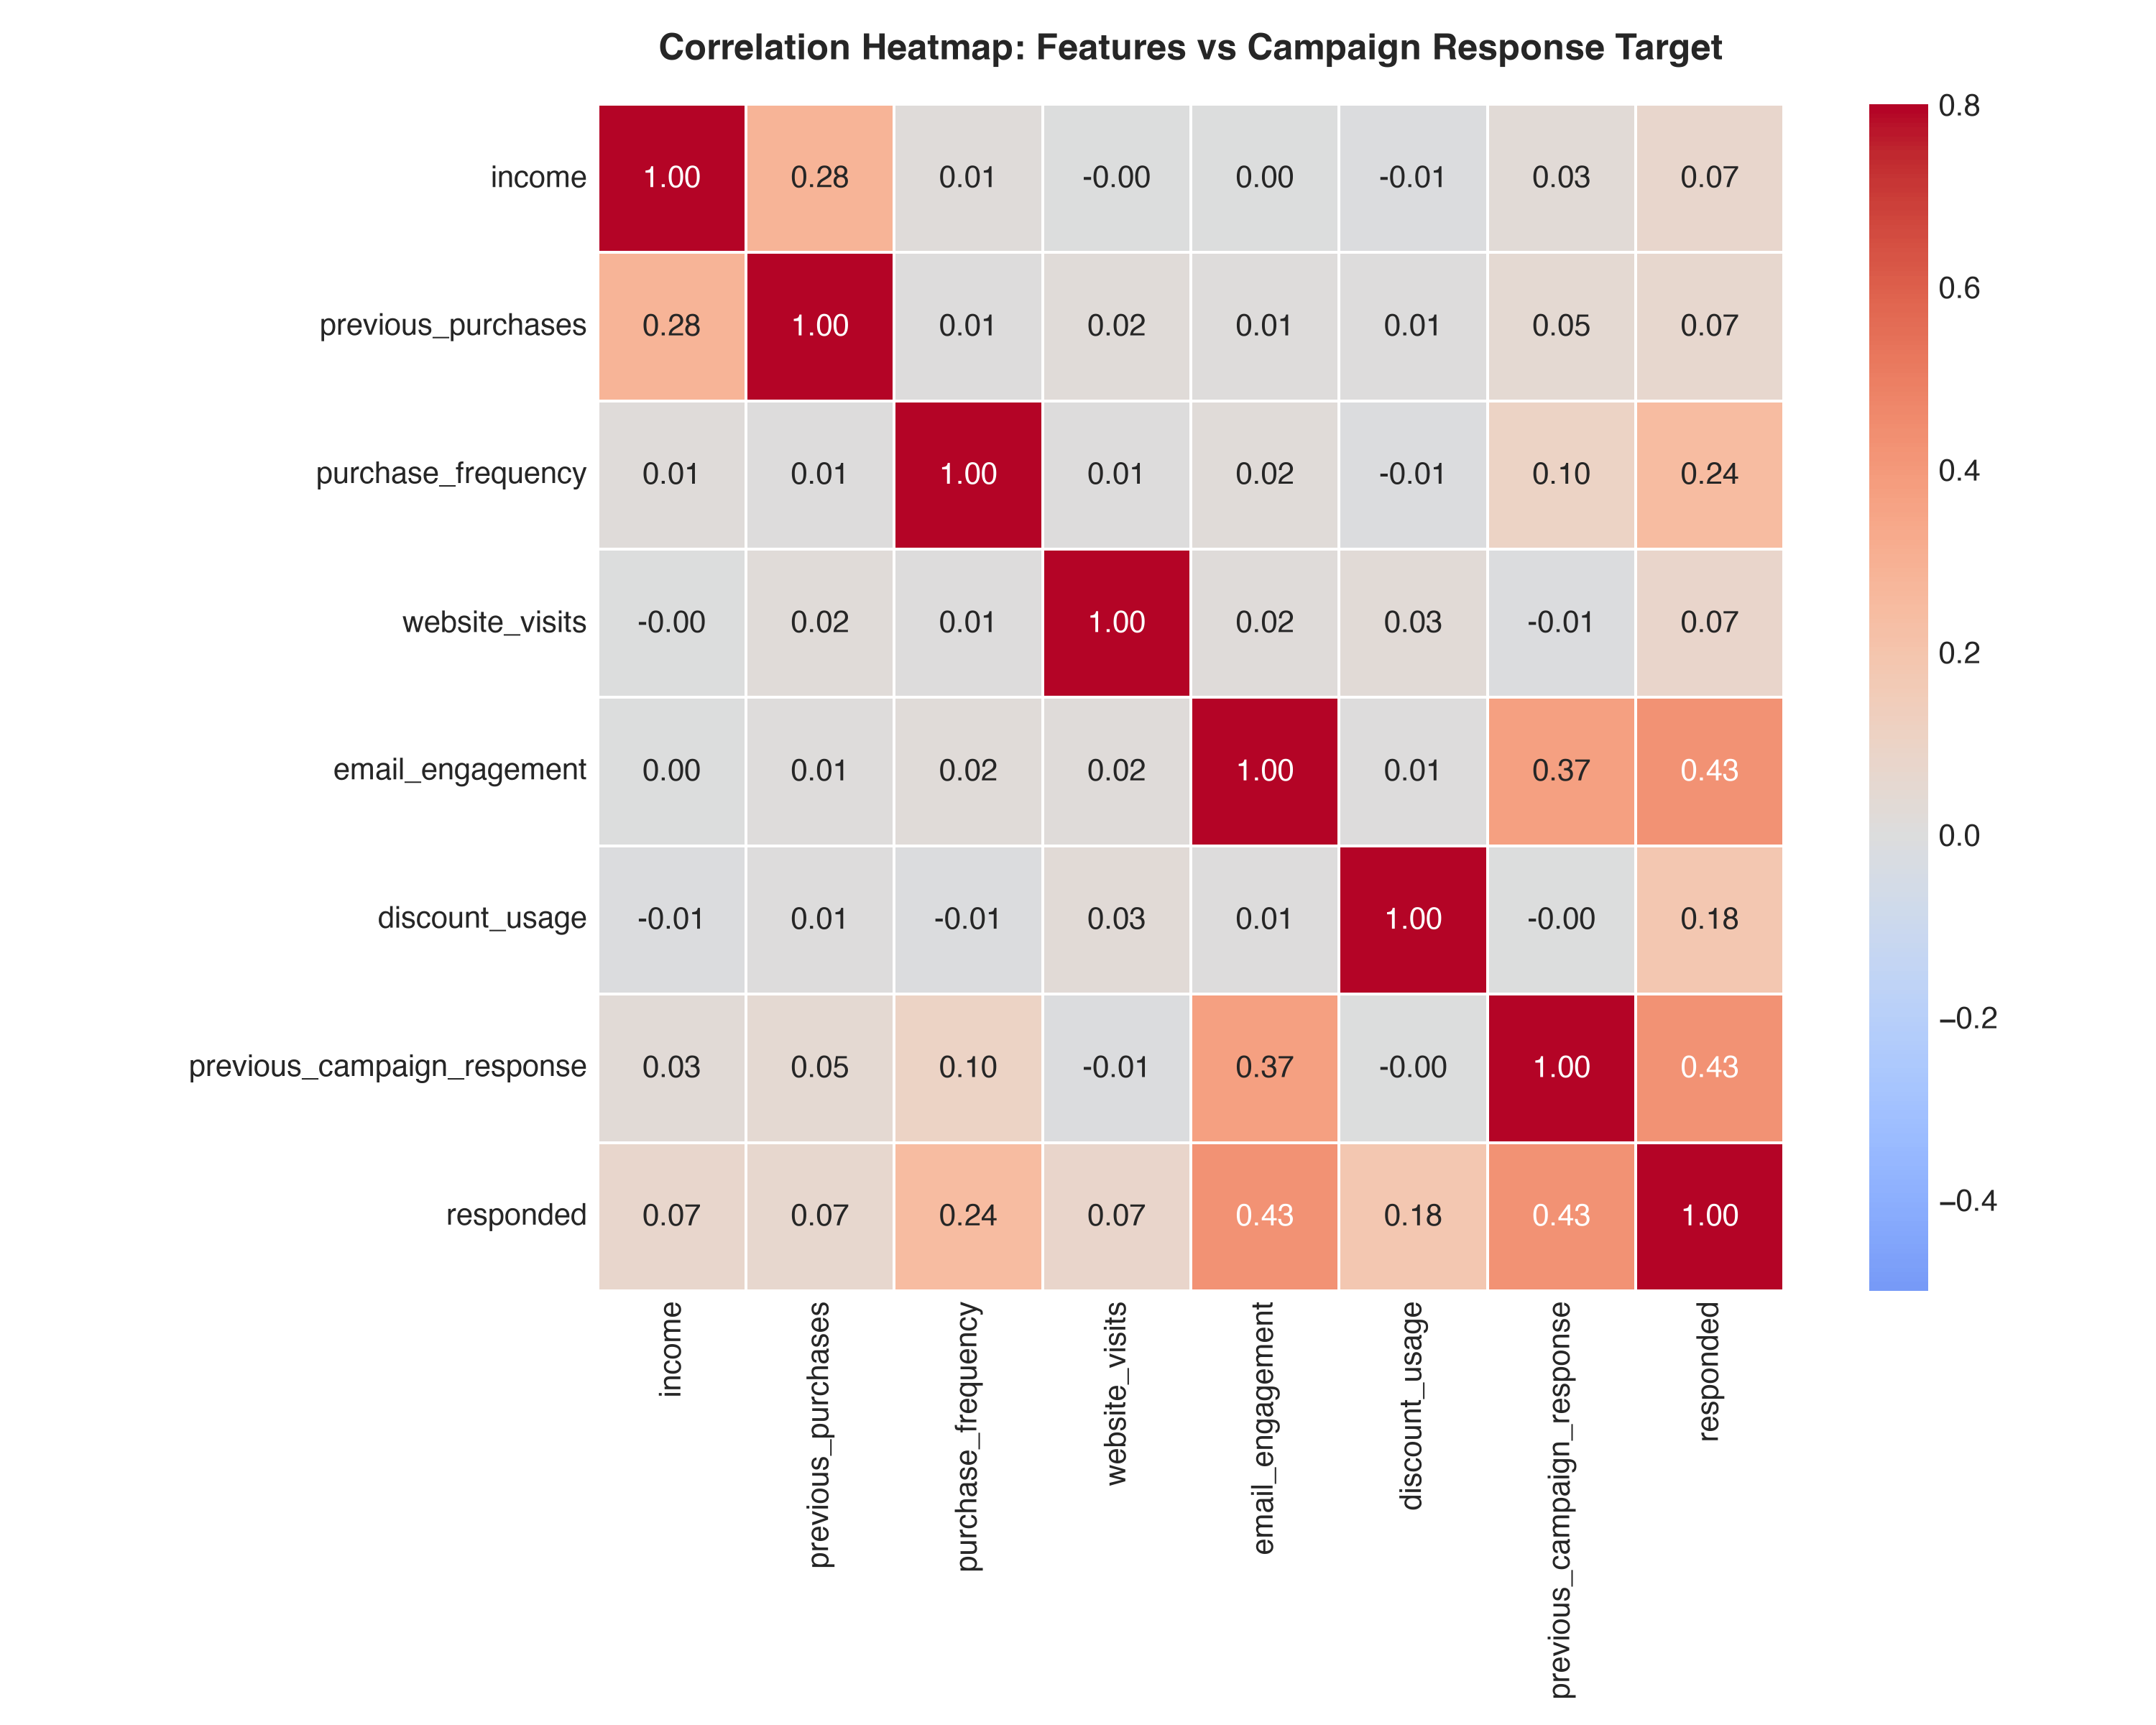

In [7]:
display(Image(filename=os.path.join(fig_dir, "eda_correlation_heatmap.png"), width=600))

## 5. Comprehensive 6-Model Benchmark & Defensible Selection
All six models were evaluated under identical 5-fold Stratified Cross-Validation on the training partition:
- **Primary Selection Metric:** 5-fold CV PR-AUC (Average Precision) and CV ROC-AUC with standard deviations.
- **Statistical Tie Rule:** Models within 1 standard deviation of the top model are disclosed as statistically tied.
- **Tie-Breaker:** Broken by lower False Positive Rate at fixed 70% recall, model simplicity, and interpretability.


In [8]:
comp_csv = os.path.join(PROJECT_ROOT, "reports", "results_comparison.csv")
results_df = pd.read_csv(comp_csv)
print("=== Algorithm Performance Benchmark on Held-Out Test Set ===")
display(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC', 'FPR', 'FPR_at_Recall_70', 'CV_PR_AUC_Mean', 'CV_PR_AUC_Std', 'CV_ROC_AUC_Mean', 'CV_ROC_AUC_Std']])


=== Algorithm Performance Benchmark on Held-Out Test Set ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,FPR,FPR_at_Recall_70,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std
0,Logistic Regression,0.872,0.787402,0.497512,0.609756,0.875871,0.728611,0.033792,0.102628,0.722297,0.026705,0.888301,0.010372
1,Gradient Boosting,0.872,0.801653,0.482587,0.602484,0.873990,0.713544,0.030038,0.121402,0.716915,0.025357,0.884490,0.007482
2,Random Forest,0.872,0.823009,0.462687,0.592357,0.874364,0.710517,0.025031,0.128911,0.714346,0.024898,0.881851,0.010168
3,K-Nearest Neighbors,0.846,0.790123,0.318408,0.453901,0.857991,0.652718,0.021277,0.150188,0.688657,0.029130,0.866314,0.013078
4,Naive Bayes,0.853,0.648352,0.587065,0.616188,0.866861,0.700708,0.080100,0.148936,0.681614,0.034649,0.875681,0.014126
5,Decision Tree,0.847,0.700000,0.417910,0.523364,0.835307,0.619519,0.045056,0.200250,0.605094,0.027601,0.838249,0.011321


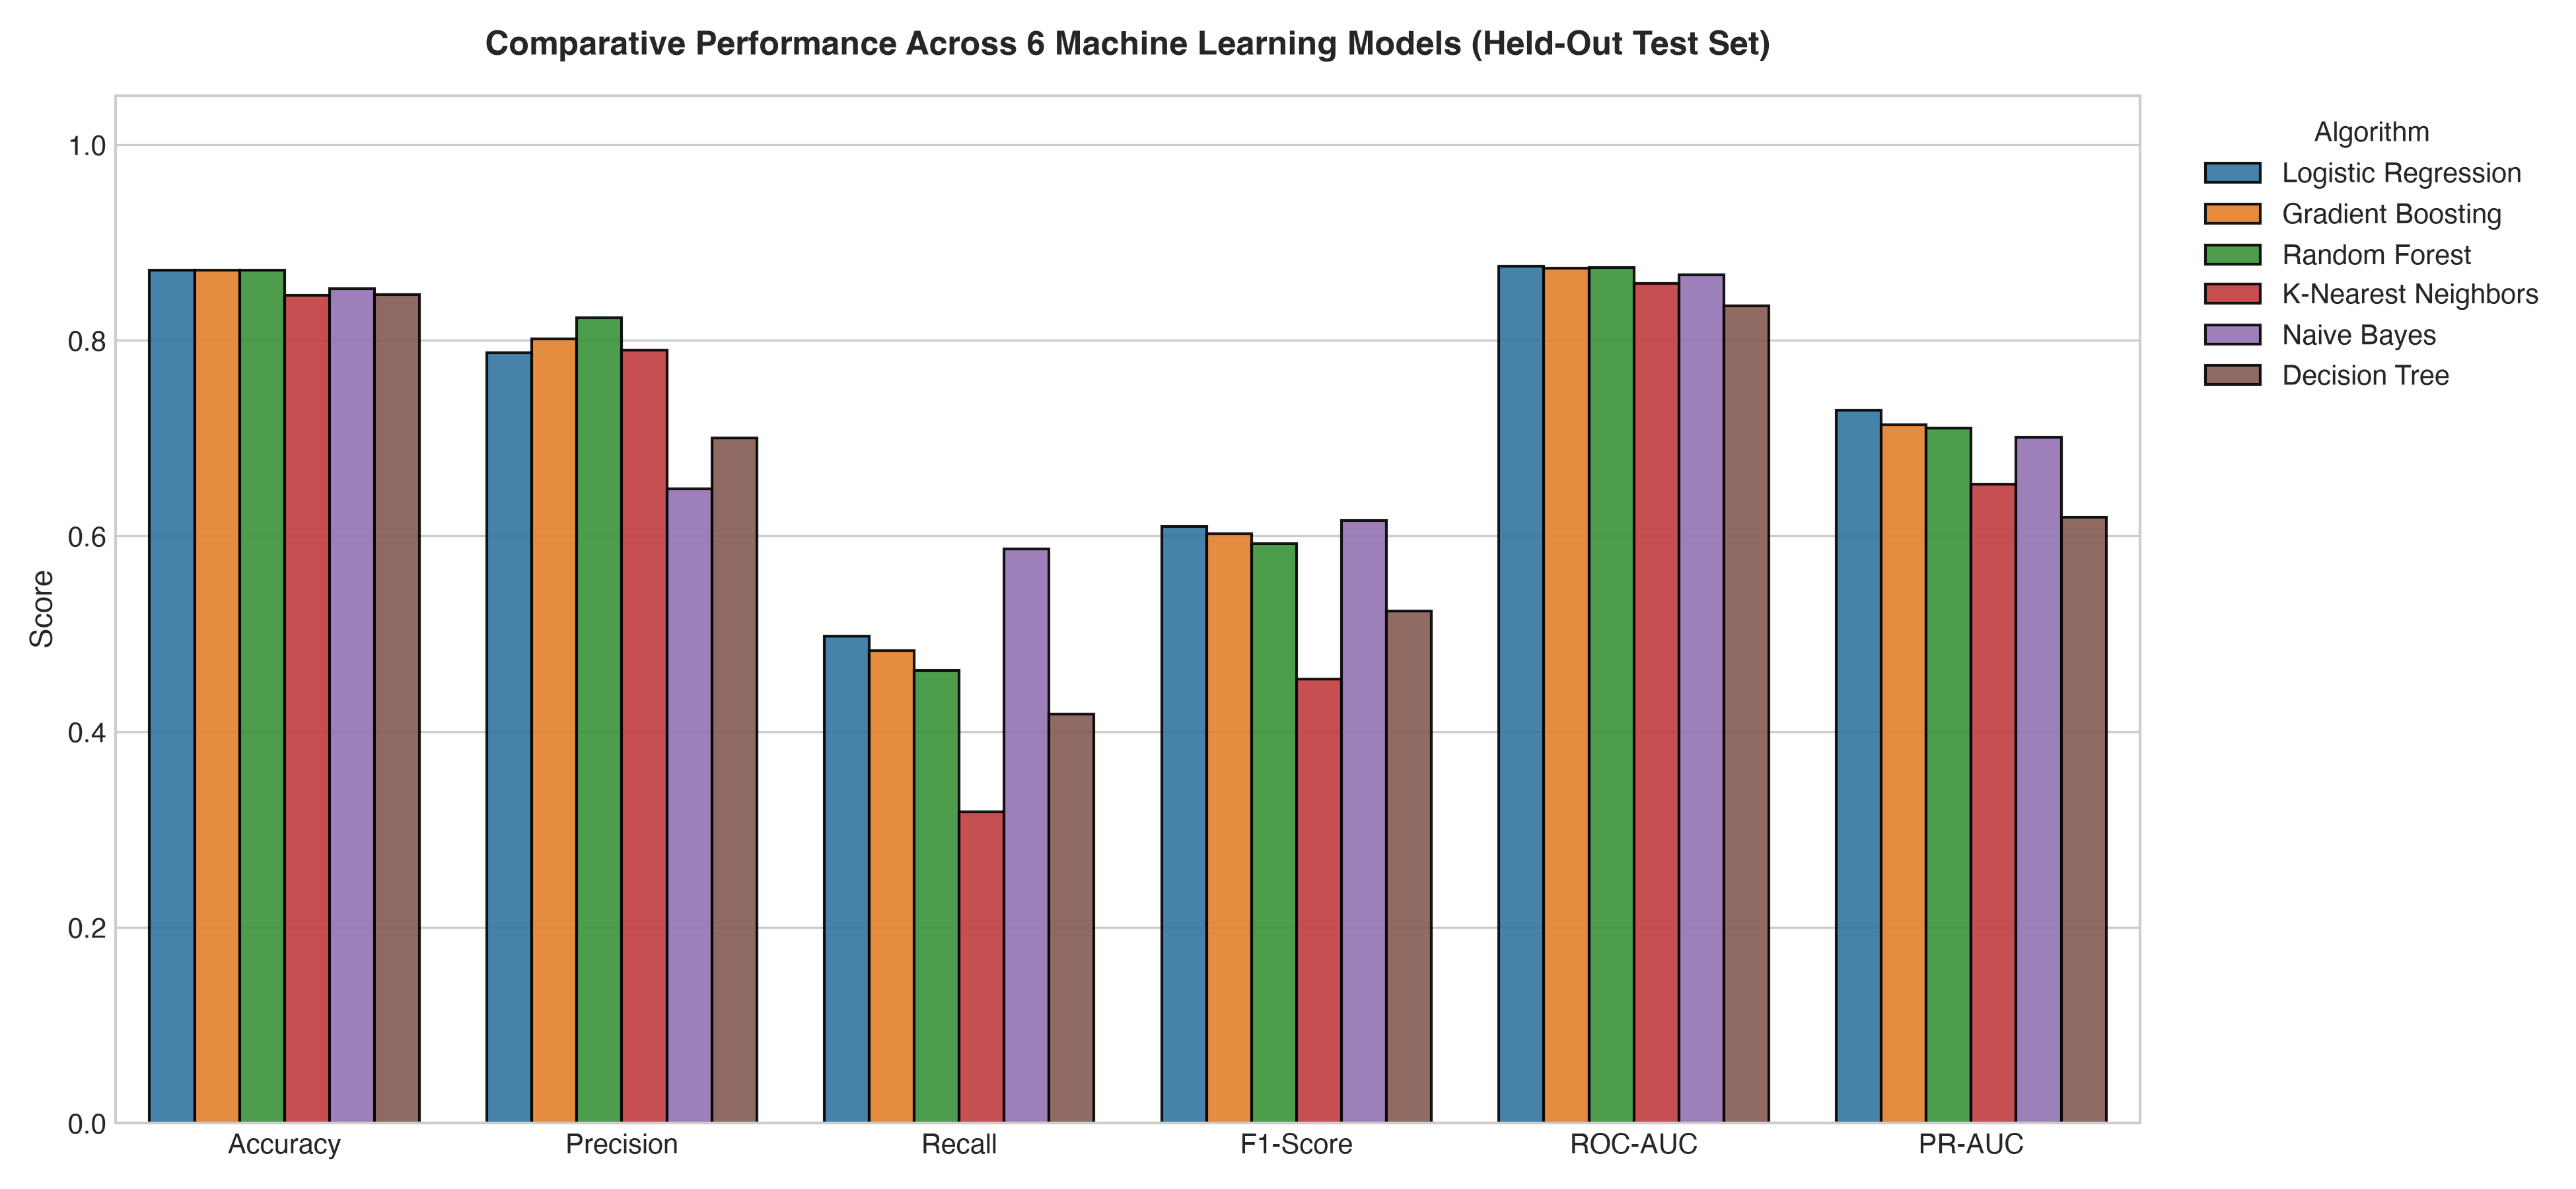

In [9]:
display(Image(filename=os.path.join(fig_dir, "metrics_comparison_bar.png"), width=700))

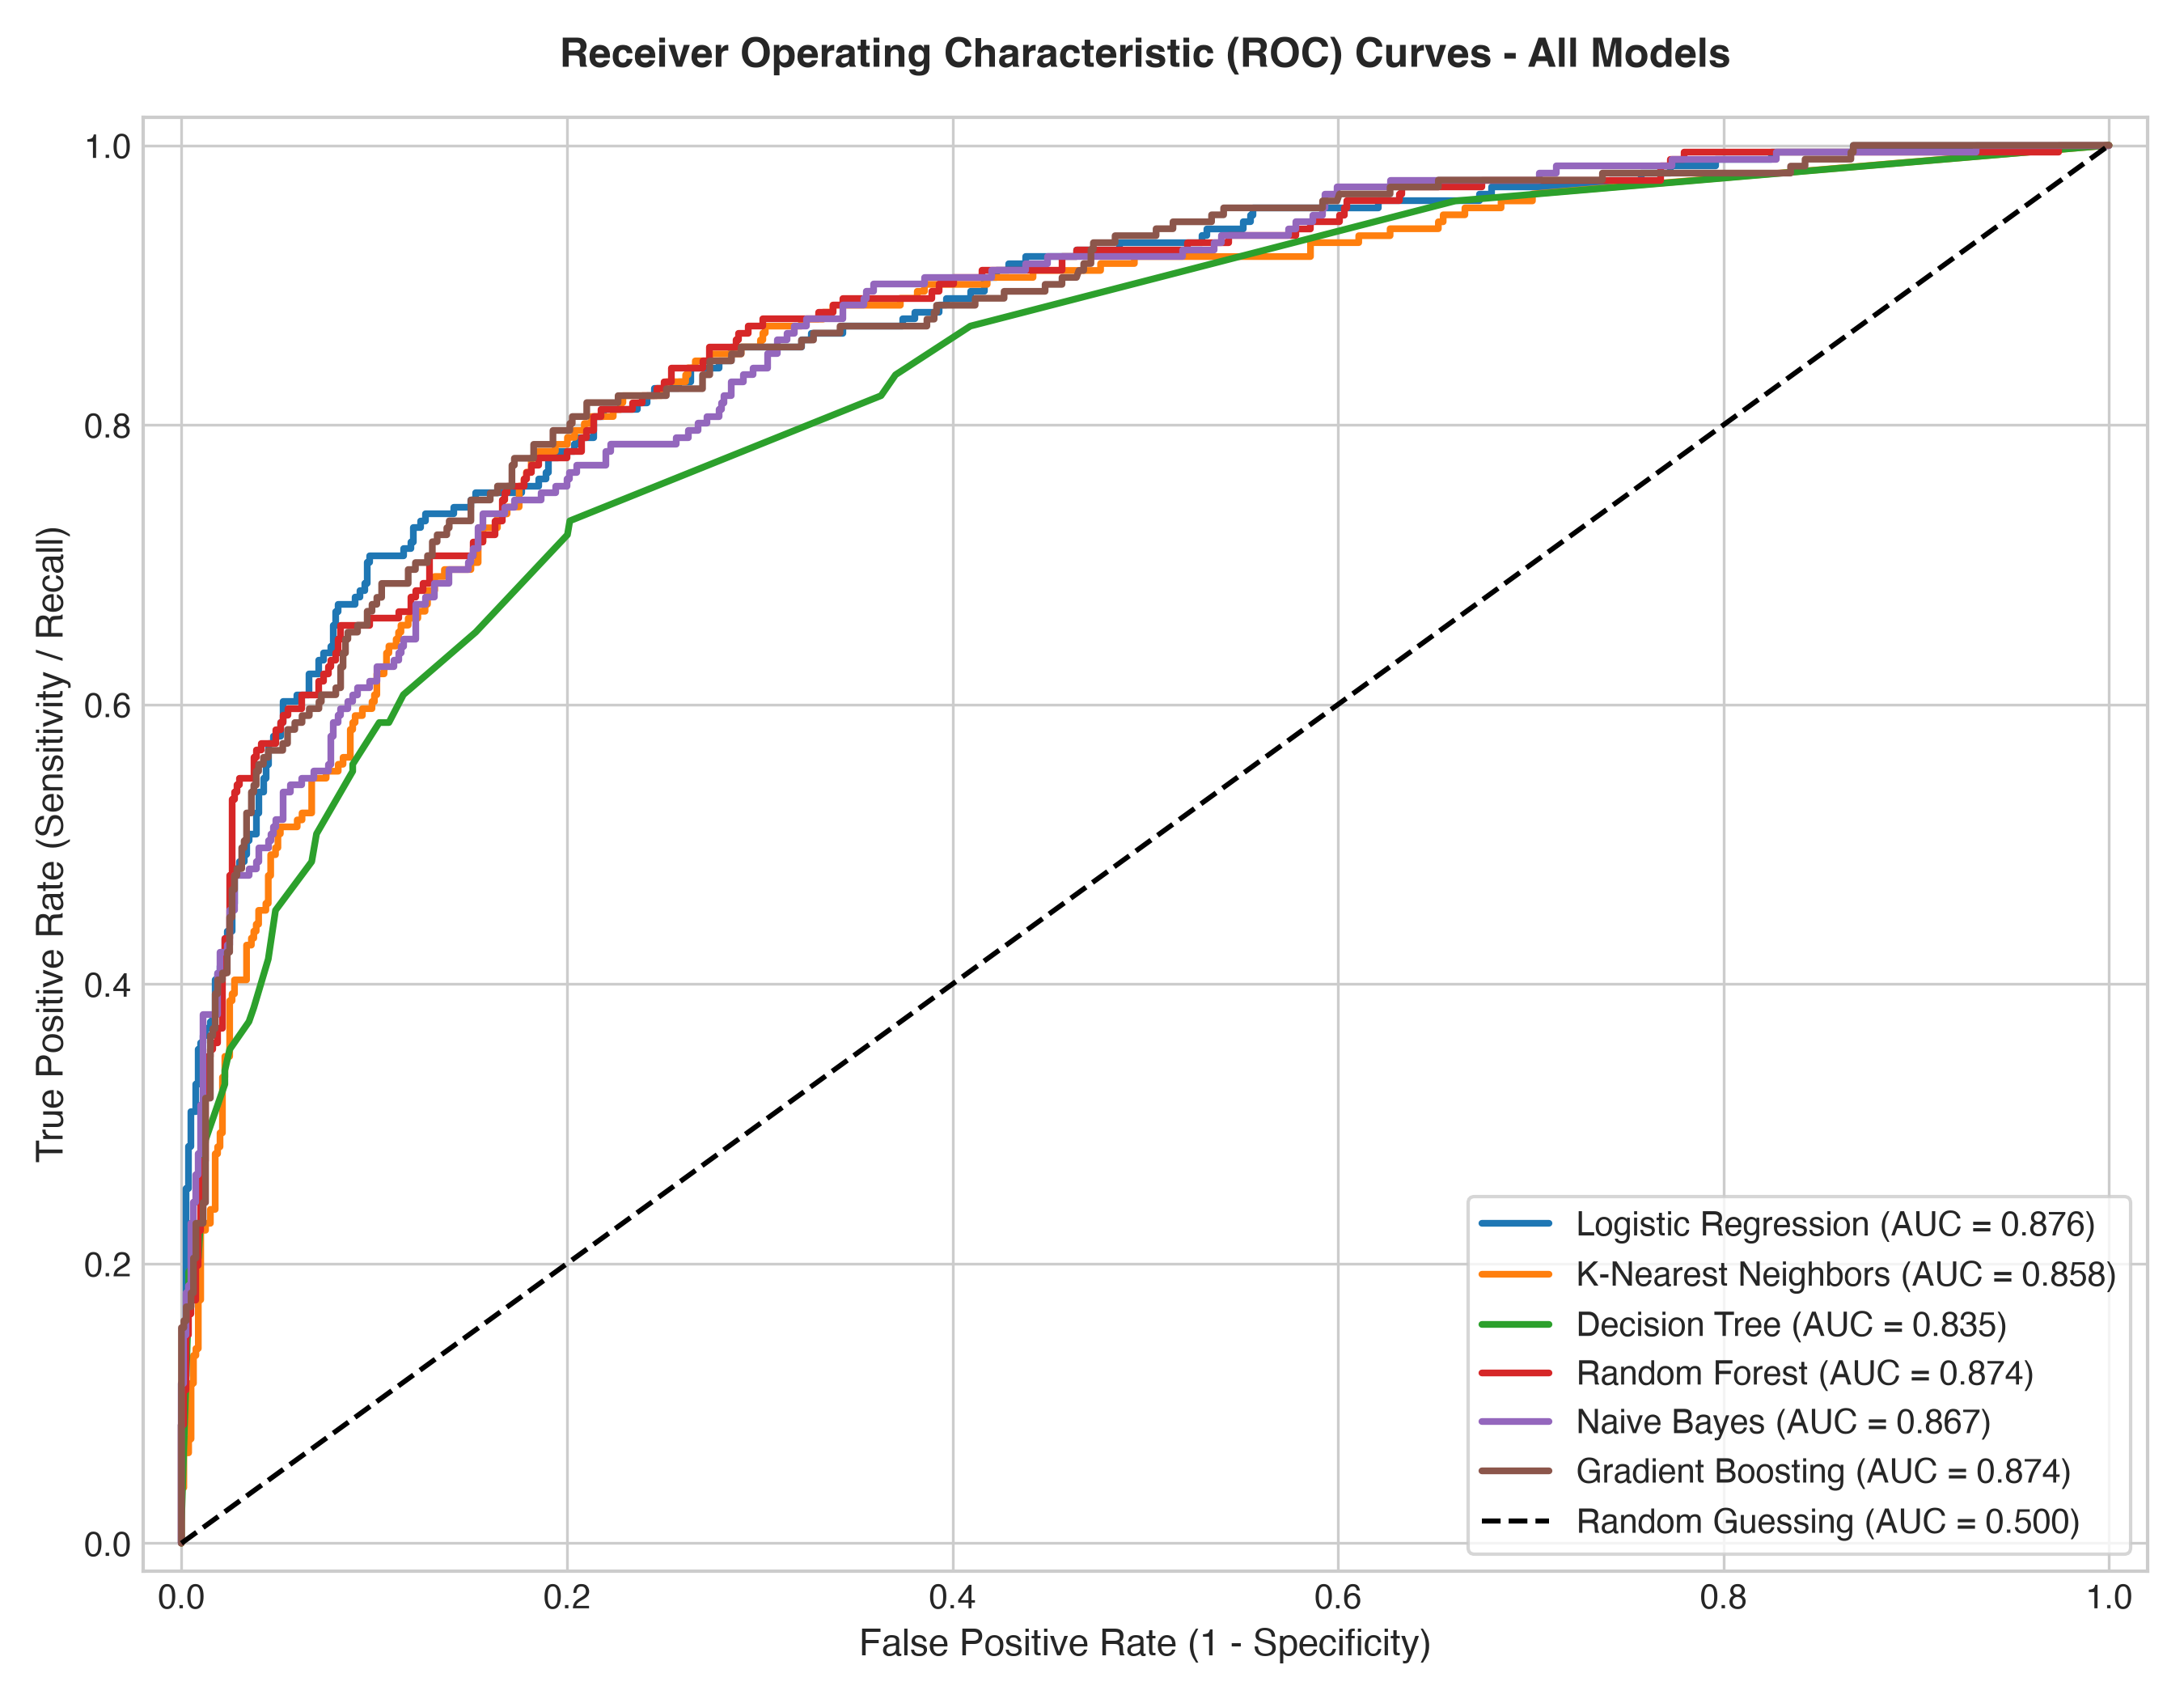

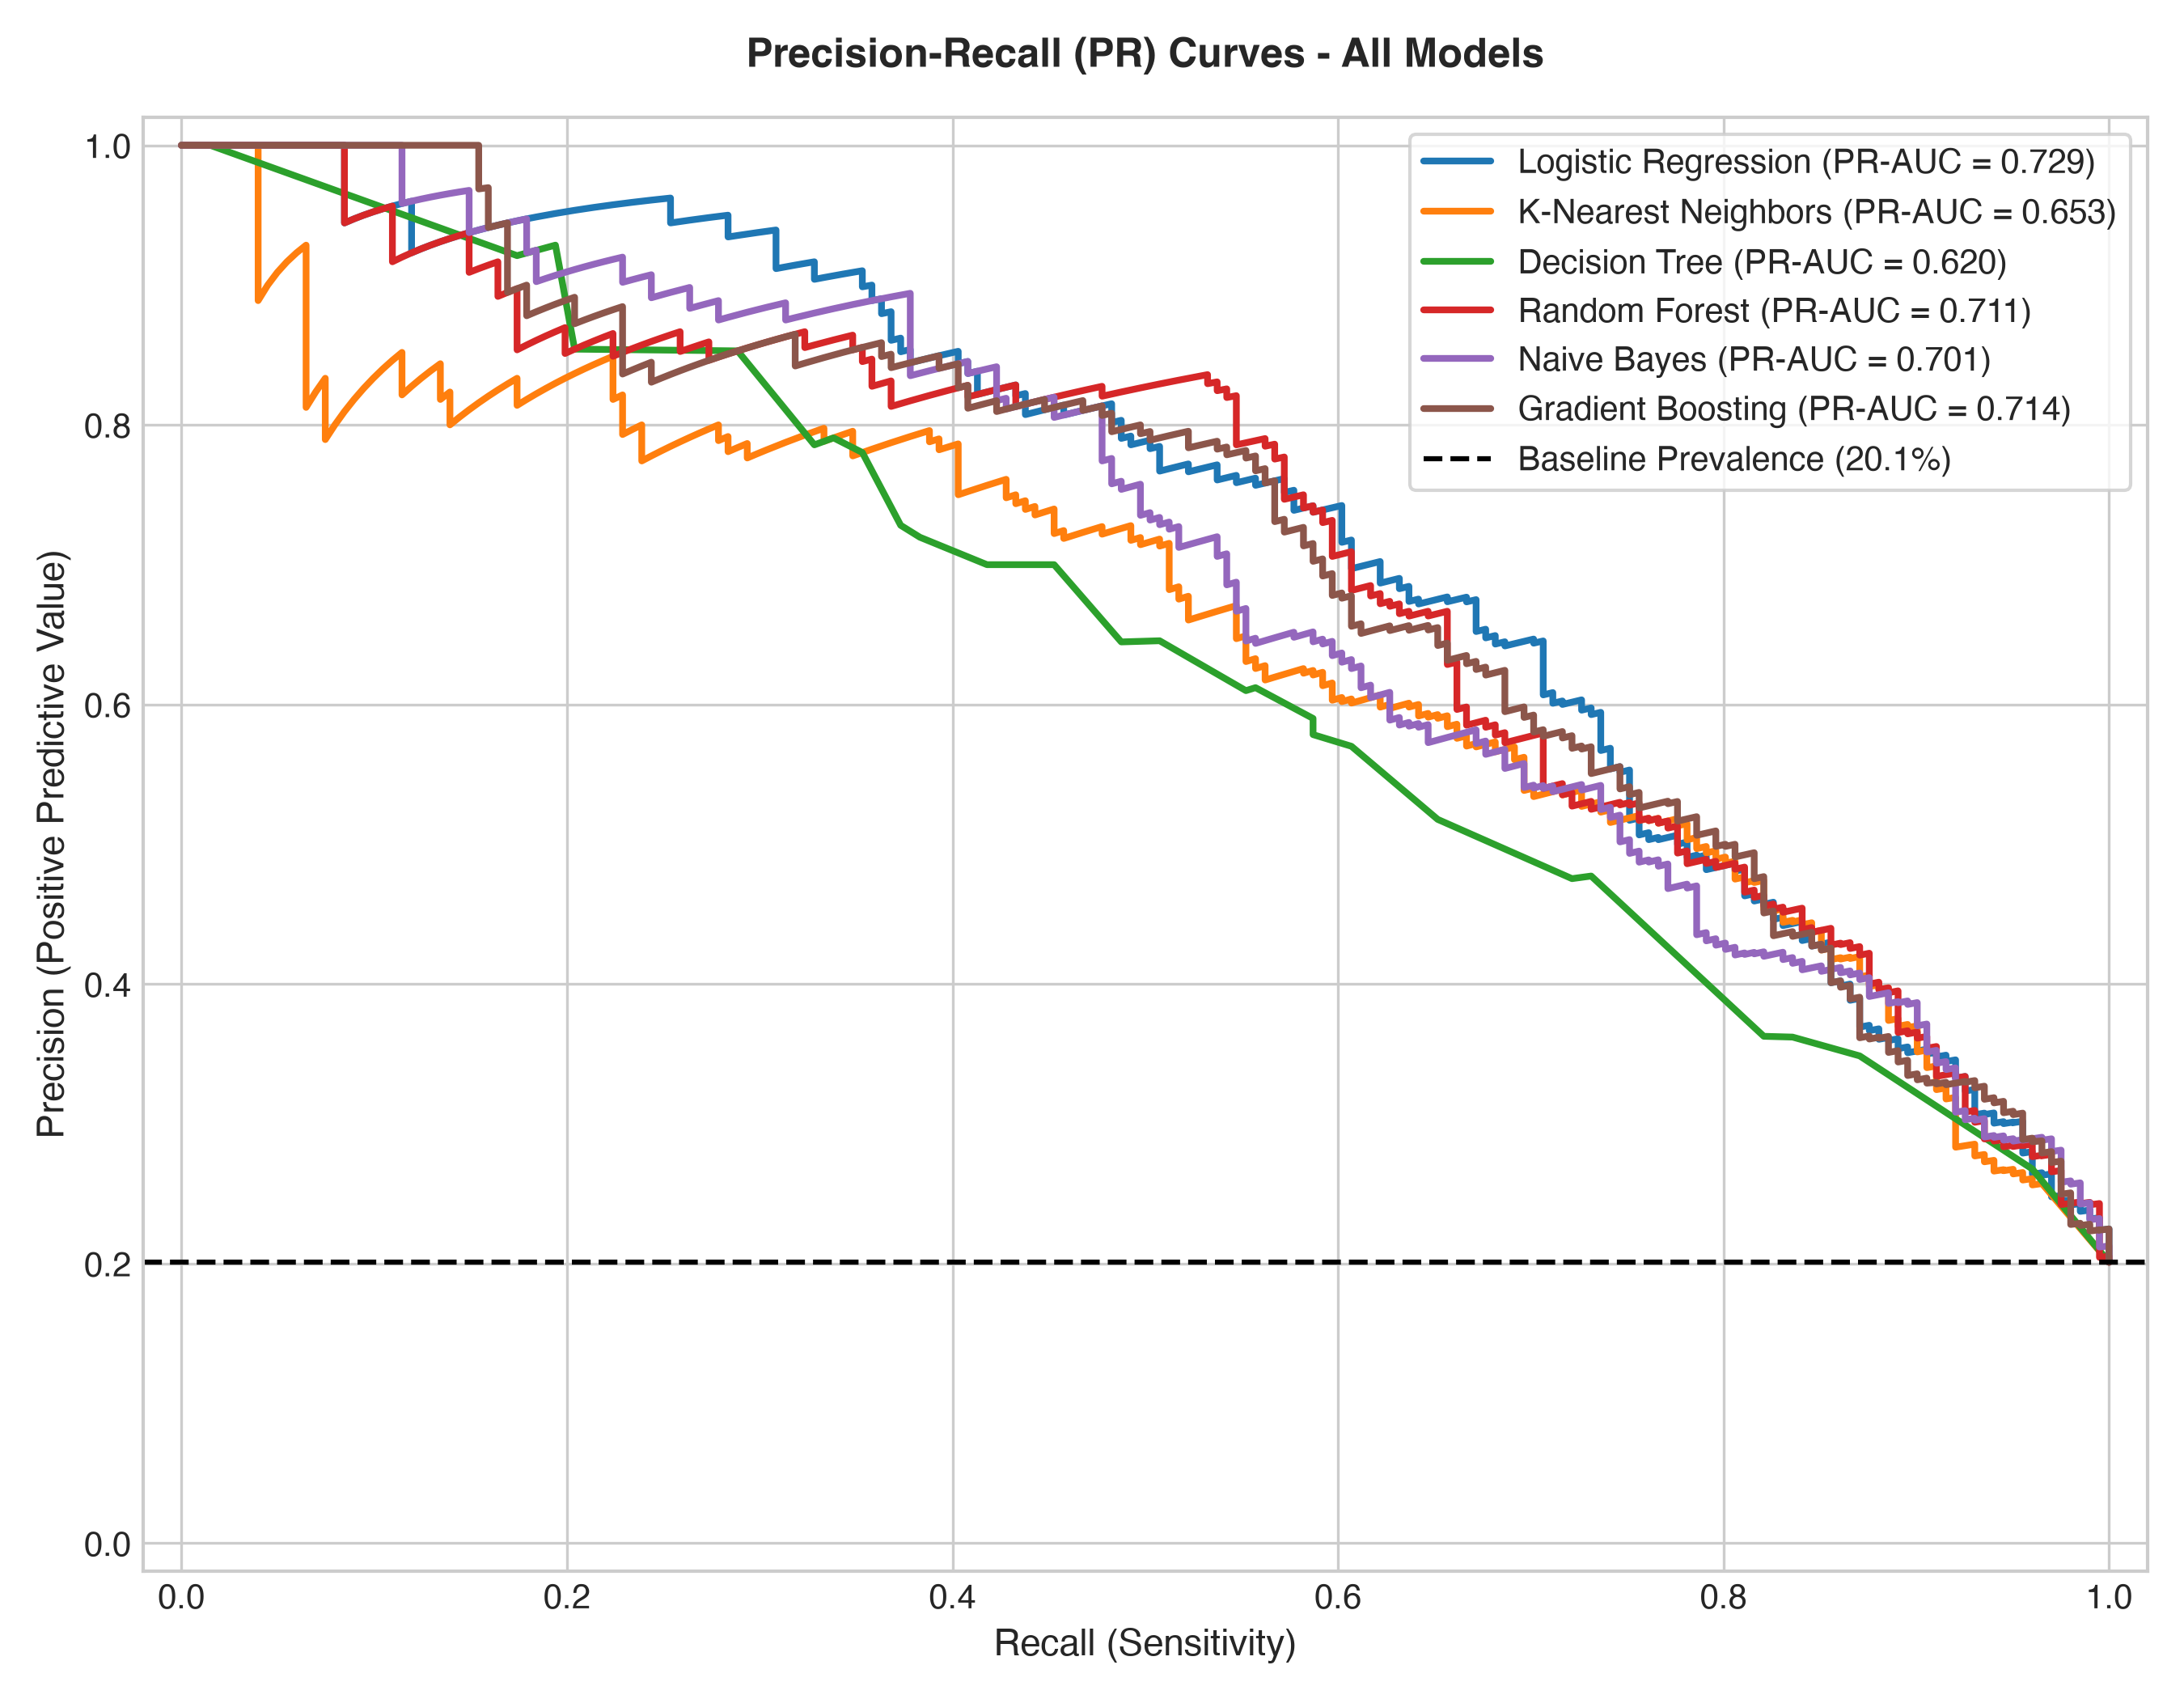

In [10]:
col_roc = Image(filename=os.path.join(fig_dir, "roc_curves_all_models.png"), width=450)
col_pr = Image(filename=os.path.join(fig_dir, "pr_curves_all_models.png"), width=450)
display(col_roc, col_pr)


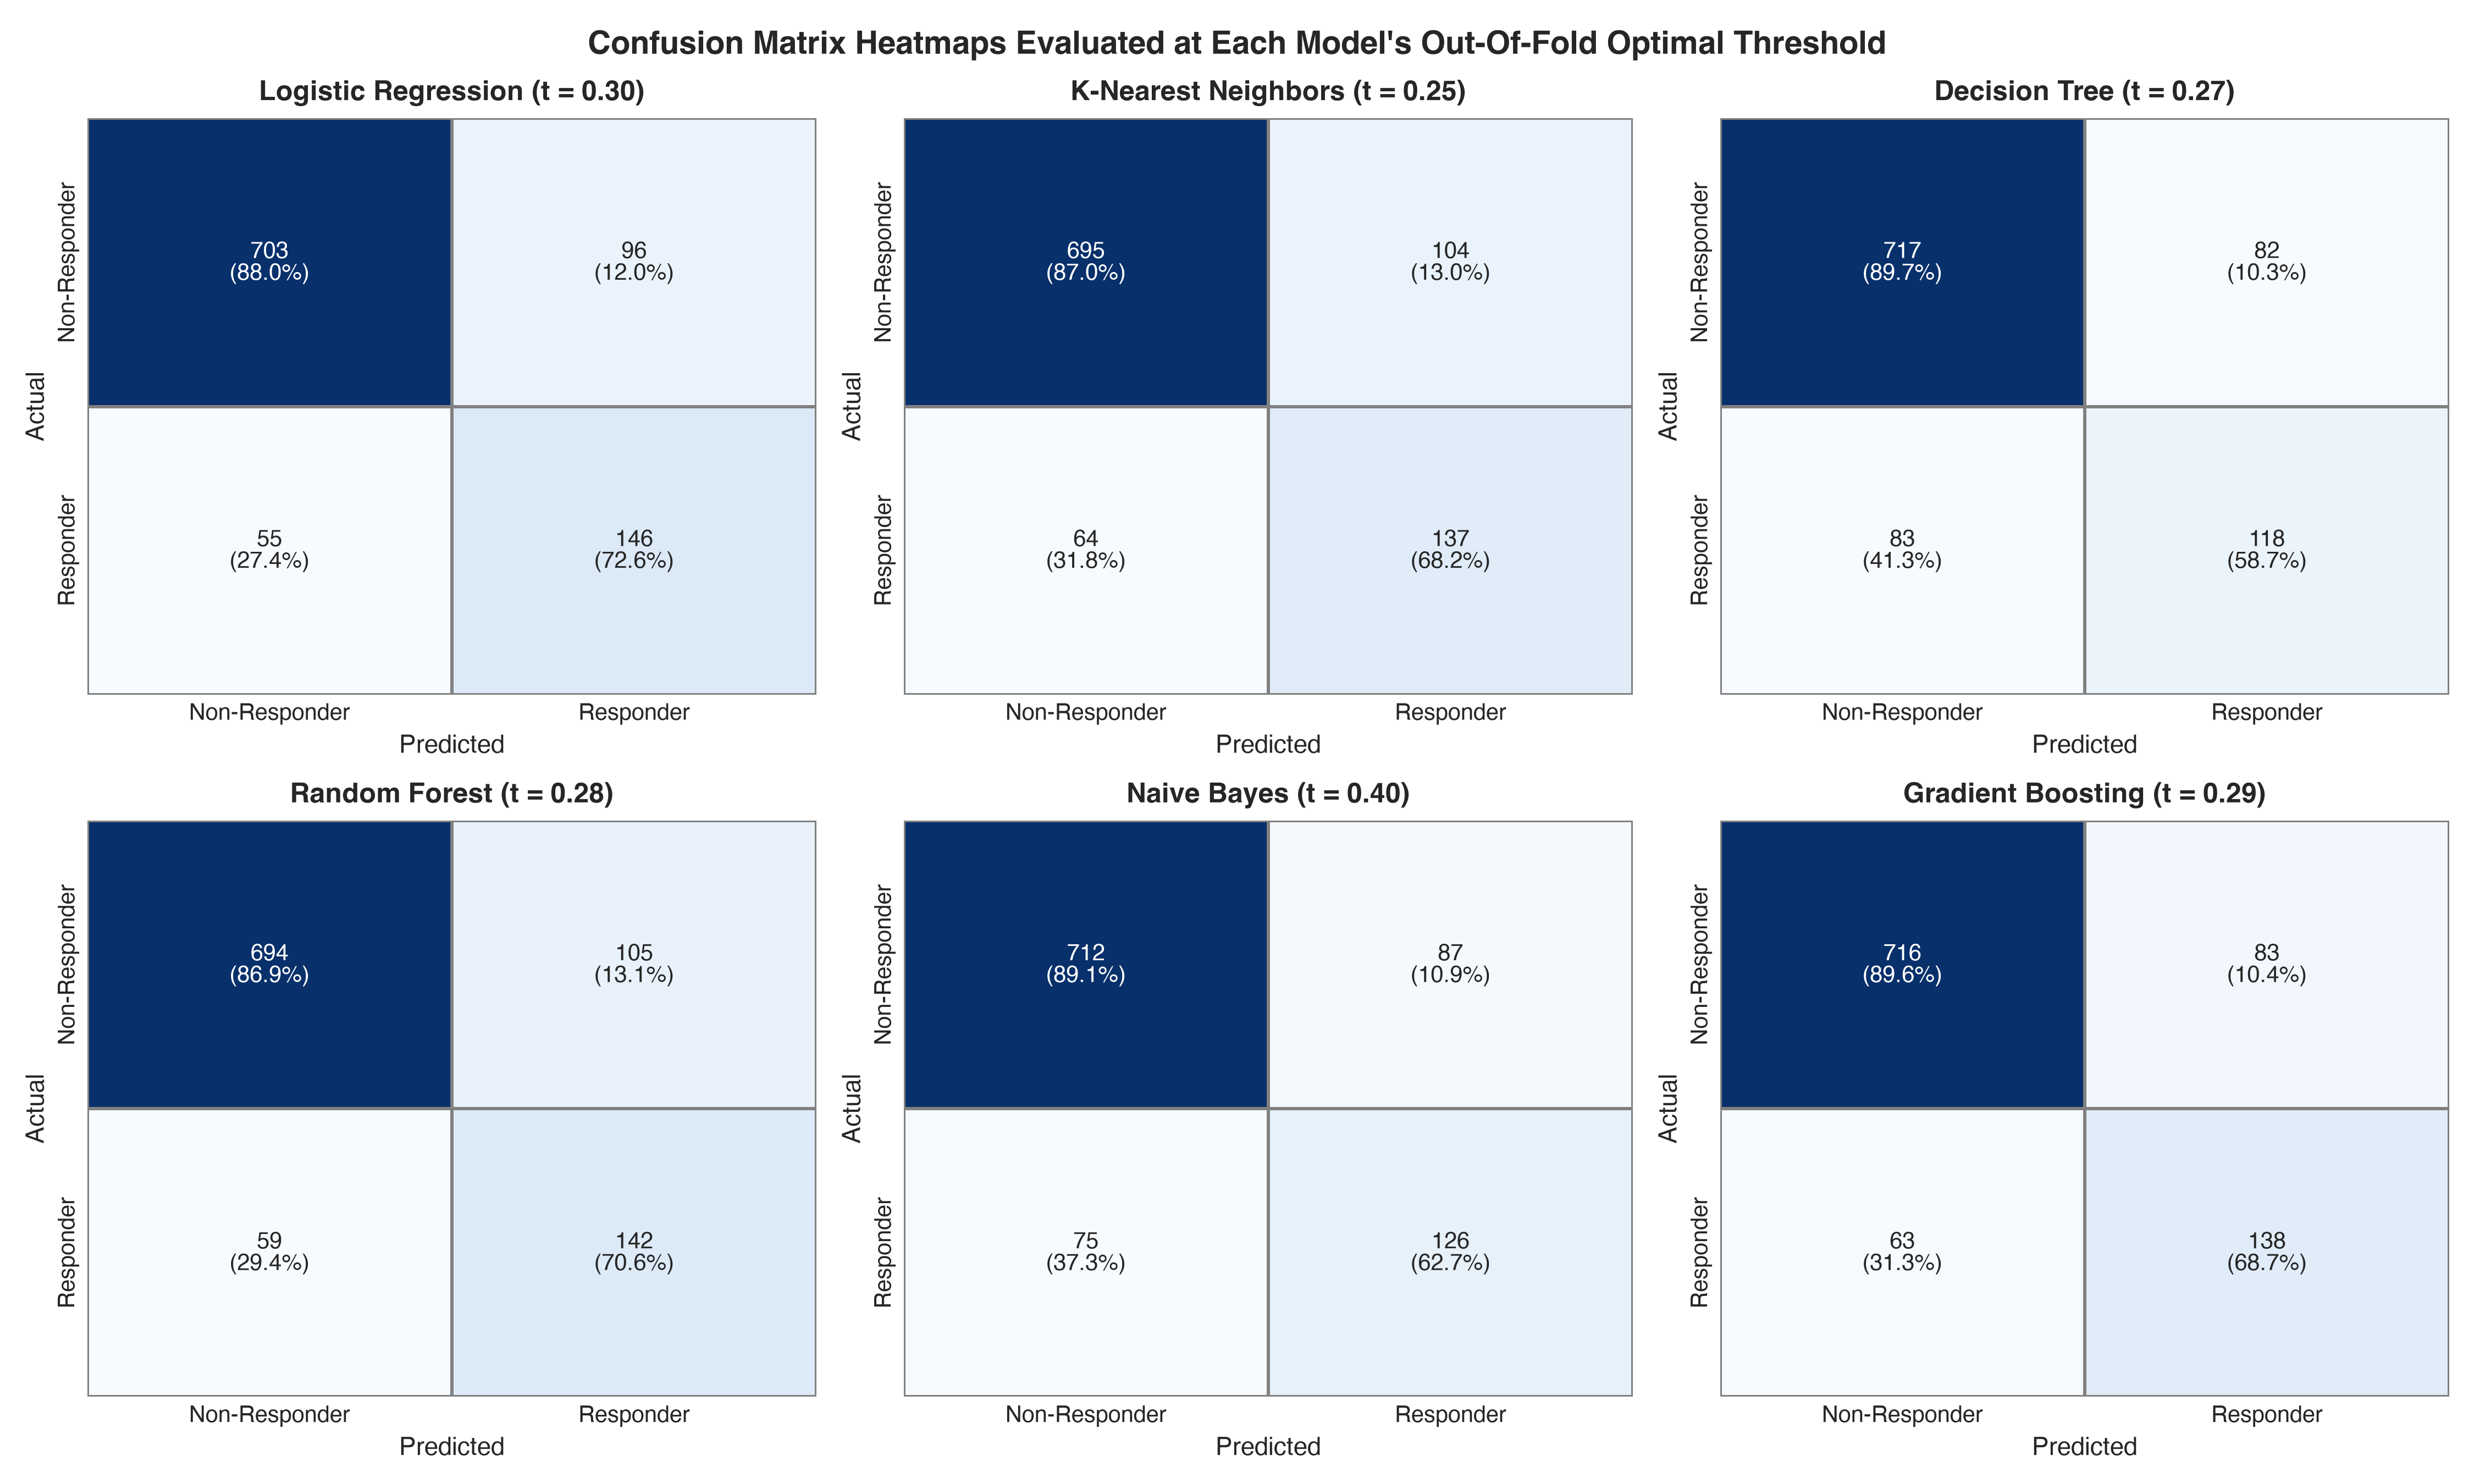

In [11]:
display(Image(filename=os.path.join(fig_dir, "confusion_matrices_grid.png"), width=700))

## 6. Class Imbalance Treatments Analysis
We compared three imbalance treatments under identical 5-fold cross-validation:
1. None (Unweighted baseline)
2. `class_weight='balanced'`
3. SMOTENC (Categorical-aware synthetic oversampling)


In [12]:
imb_csv = os.path.join(PROJECT_ROOT, "reports", "imbalance_handling_comparison.csv")
imb_df = pd.read_csv(imb_csv)
print("=== Imbalance Treatment Comparison (5-Fold CV PR-AUC & ROC-AUC) ===")
display(imb_df)


=== Imbalance Treatment Comparison (5-Fold CV PR-AUC & ROC-AUC) ===


,Treatment,CV_PR_AUC_Mean,CV_PR_AUC_Std,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Test_PR_AUC,Test_ROC_AUC,Test_F1_at_0.50
0,None (Unweighted Baseline),0.722297,0.026705,0.888301,0.010372,0.728611,0.875871,0.609756
1,class_weight='balanced',0.720423,0.027482,0.887763,0.010727,0.729717,0.876892,0.609037
2,SMOTENC (Categorical-aware Oversampling),0.715328,0.018778,0.884319,0.010812,0.725002,0.877720,0.614173


**Empirical Finding:** Class imbalance handling primarily shifts the uncalibrated probability threshold rather than improving ranking discrimination (PR-AUC is ~0.72 across all three treatments). Explicit decision threshold tuning on calibrated probabilities is more effective and avoids distortion.


## 7. Dual Threshold Optimization & Economic Business Simulation
Thresholds were tuned exclusively on training Out-Of-Fold (OOF) cross-validation predictions:
- **F1-Optimal Threshold ($t = 0.30$):** Maximizes harmonic mean of precision and recall.
- **Profit-Optimal Threshold ($t = 0.07$):** Derived from the economic break-even probability ($r = \$5.00 / \$50.00 = 0.10$).

The four strategies were evaluated once on the untouched held-out test cohort:


In [13]:
sim_csv = os.path.join(PROJECT_ROOT, "reports", "business_simulation.csv")
sim_df = pd.read_csv(sim_csv)
print("=== 4-Strategy Economic Business Simulation on Held-Out Test Set ===")
display(sim_df)


=== 4-Strategy Economic Business Simulation on Held-Out Test Set ===


,Strategy,Threshold,Targeted Contacts,Total Cost ($),Responders Reached,Wasted Contacts (FP),Gross Revenue ($),Net Profit ($),ROI (%),Cost Saved vs All (%)
0,Strategy 1: Contact Everyone,0.00,1000,5000.0,201,799,10050.0,5050.0,101.000000,0.0
1,Strategy 2: Default ML (Threshold 0.50),0.50,127,635.0,100,27,5000.0,4365.0,687.401575,87.3
2,Strategy 3: F1-Optimal (Threshold 0.30),0.30,234,1170.0,143,91,7150.0,5980.0,511.111111,76.6
3,Strategy 4: Profit-Optimal (Threshold 0.07),0.07,534,2670.0,183,351,9150.0,6480.0,242.696629,46.6


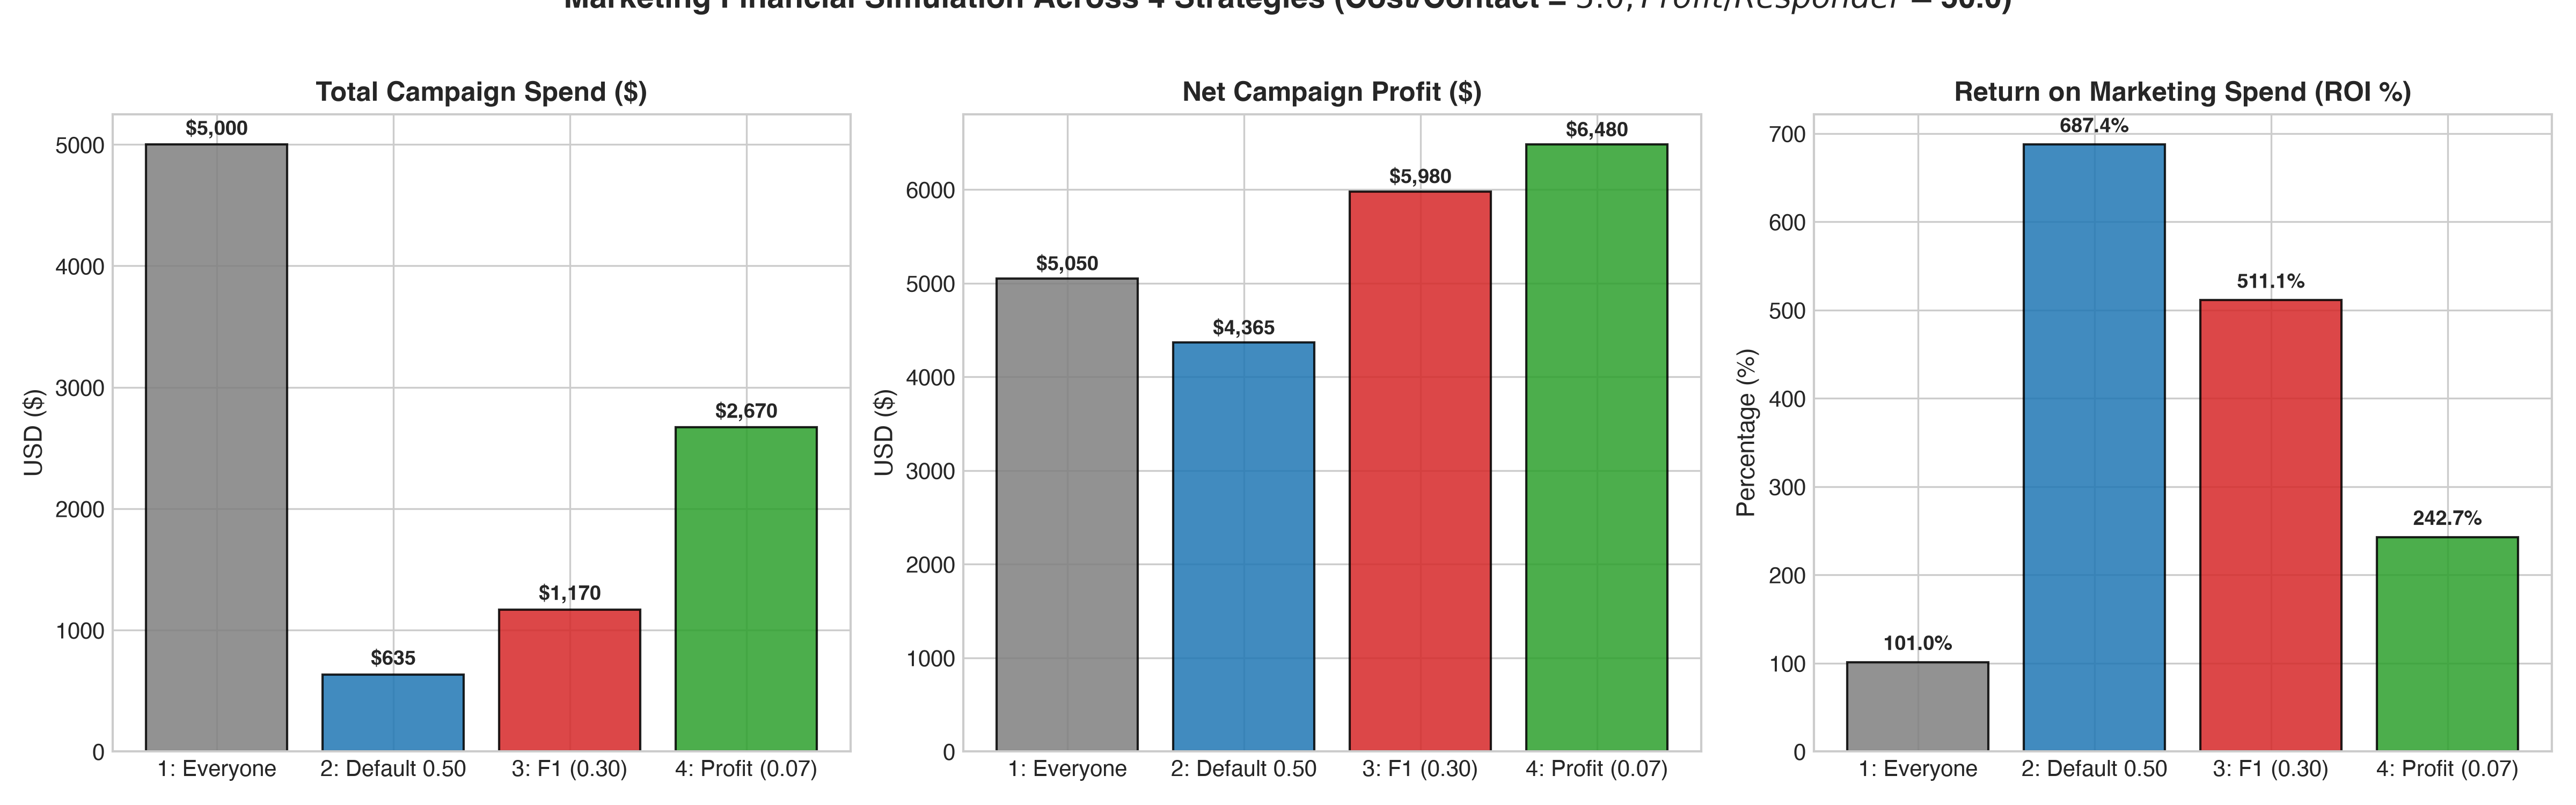

In [14]:
display(Image(filename=os.path.join(fig_dir, "business_simulation_roi.png"), width=750))

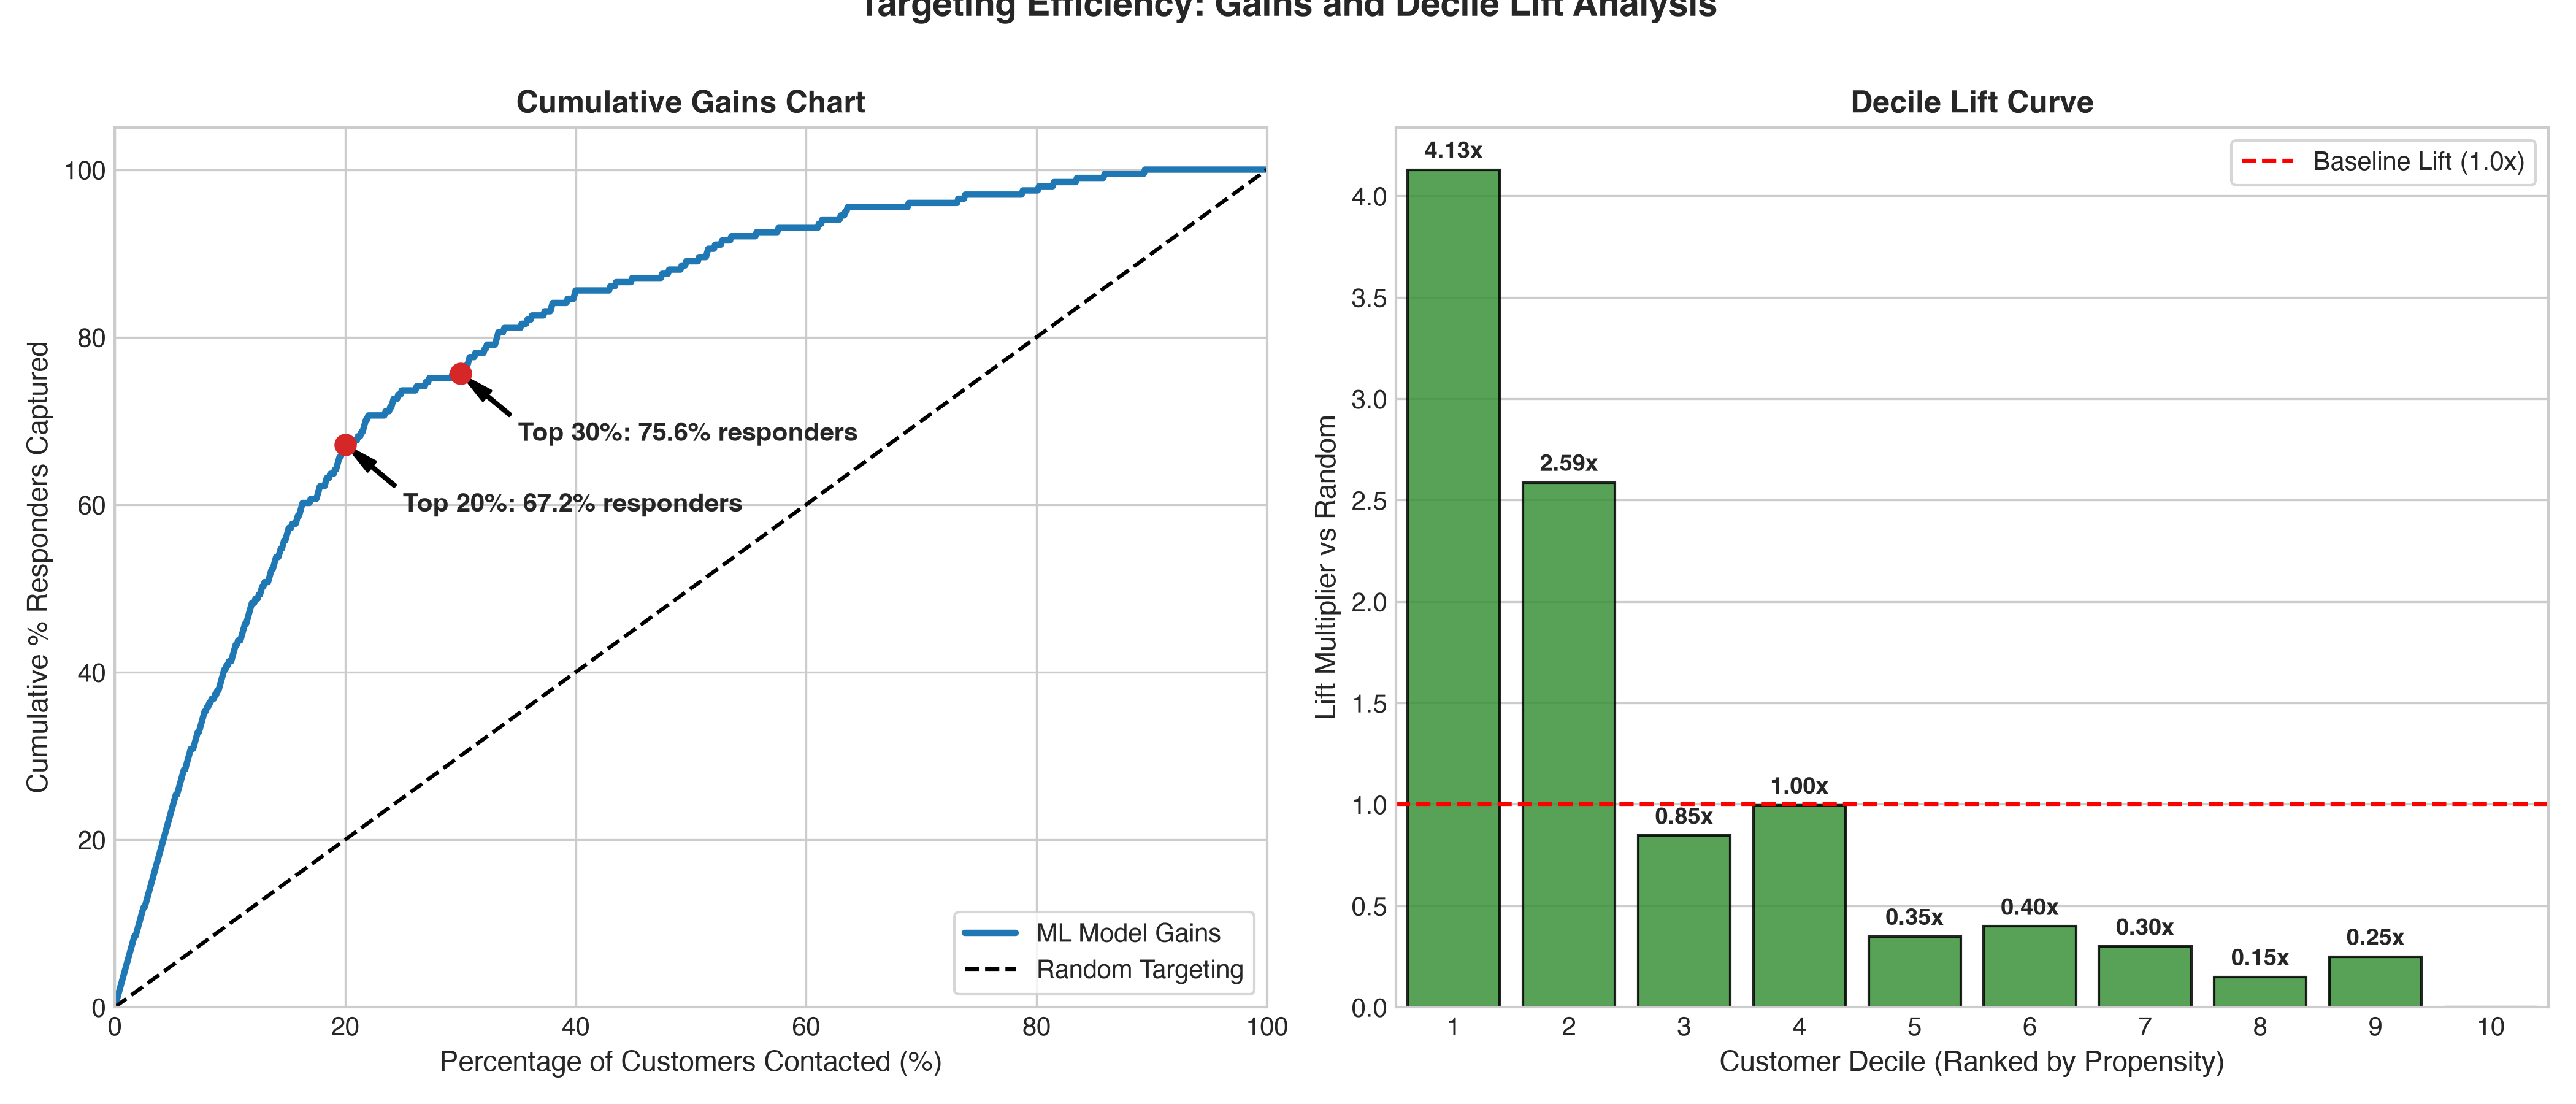

In [15]:
display(Image(filename=os.path.join(fig_dir, "cumulative_gains_lift.png"), width=750))

## 8. Probability Calibration (FrozenEstimator)
Using scikit-learn's modern `FrozenEstimator` wrapped within `CalibratedClassifierCV`, we calibrated probabilities on validation data and evaluated Brier scores:


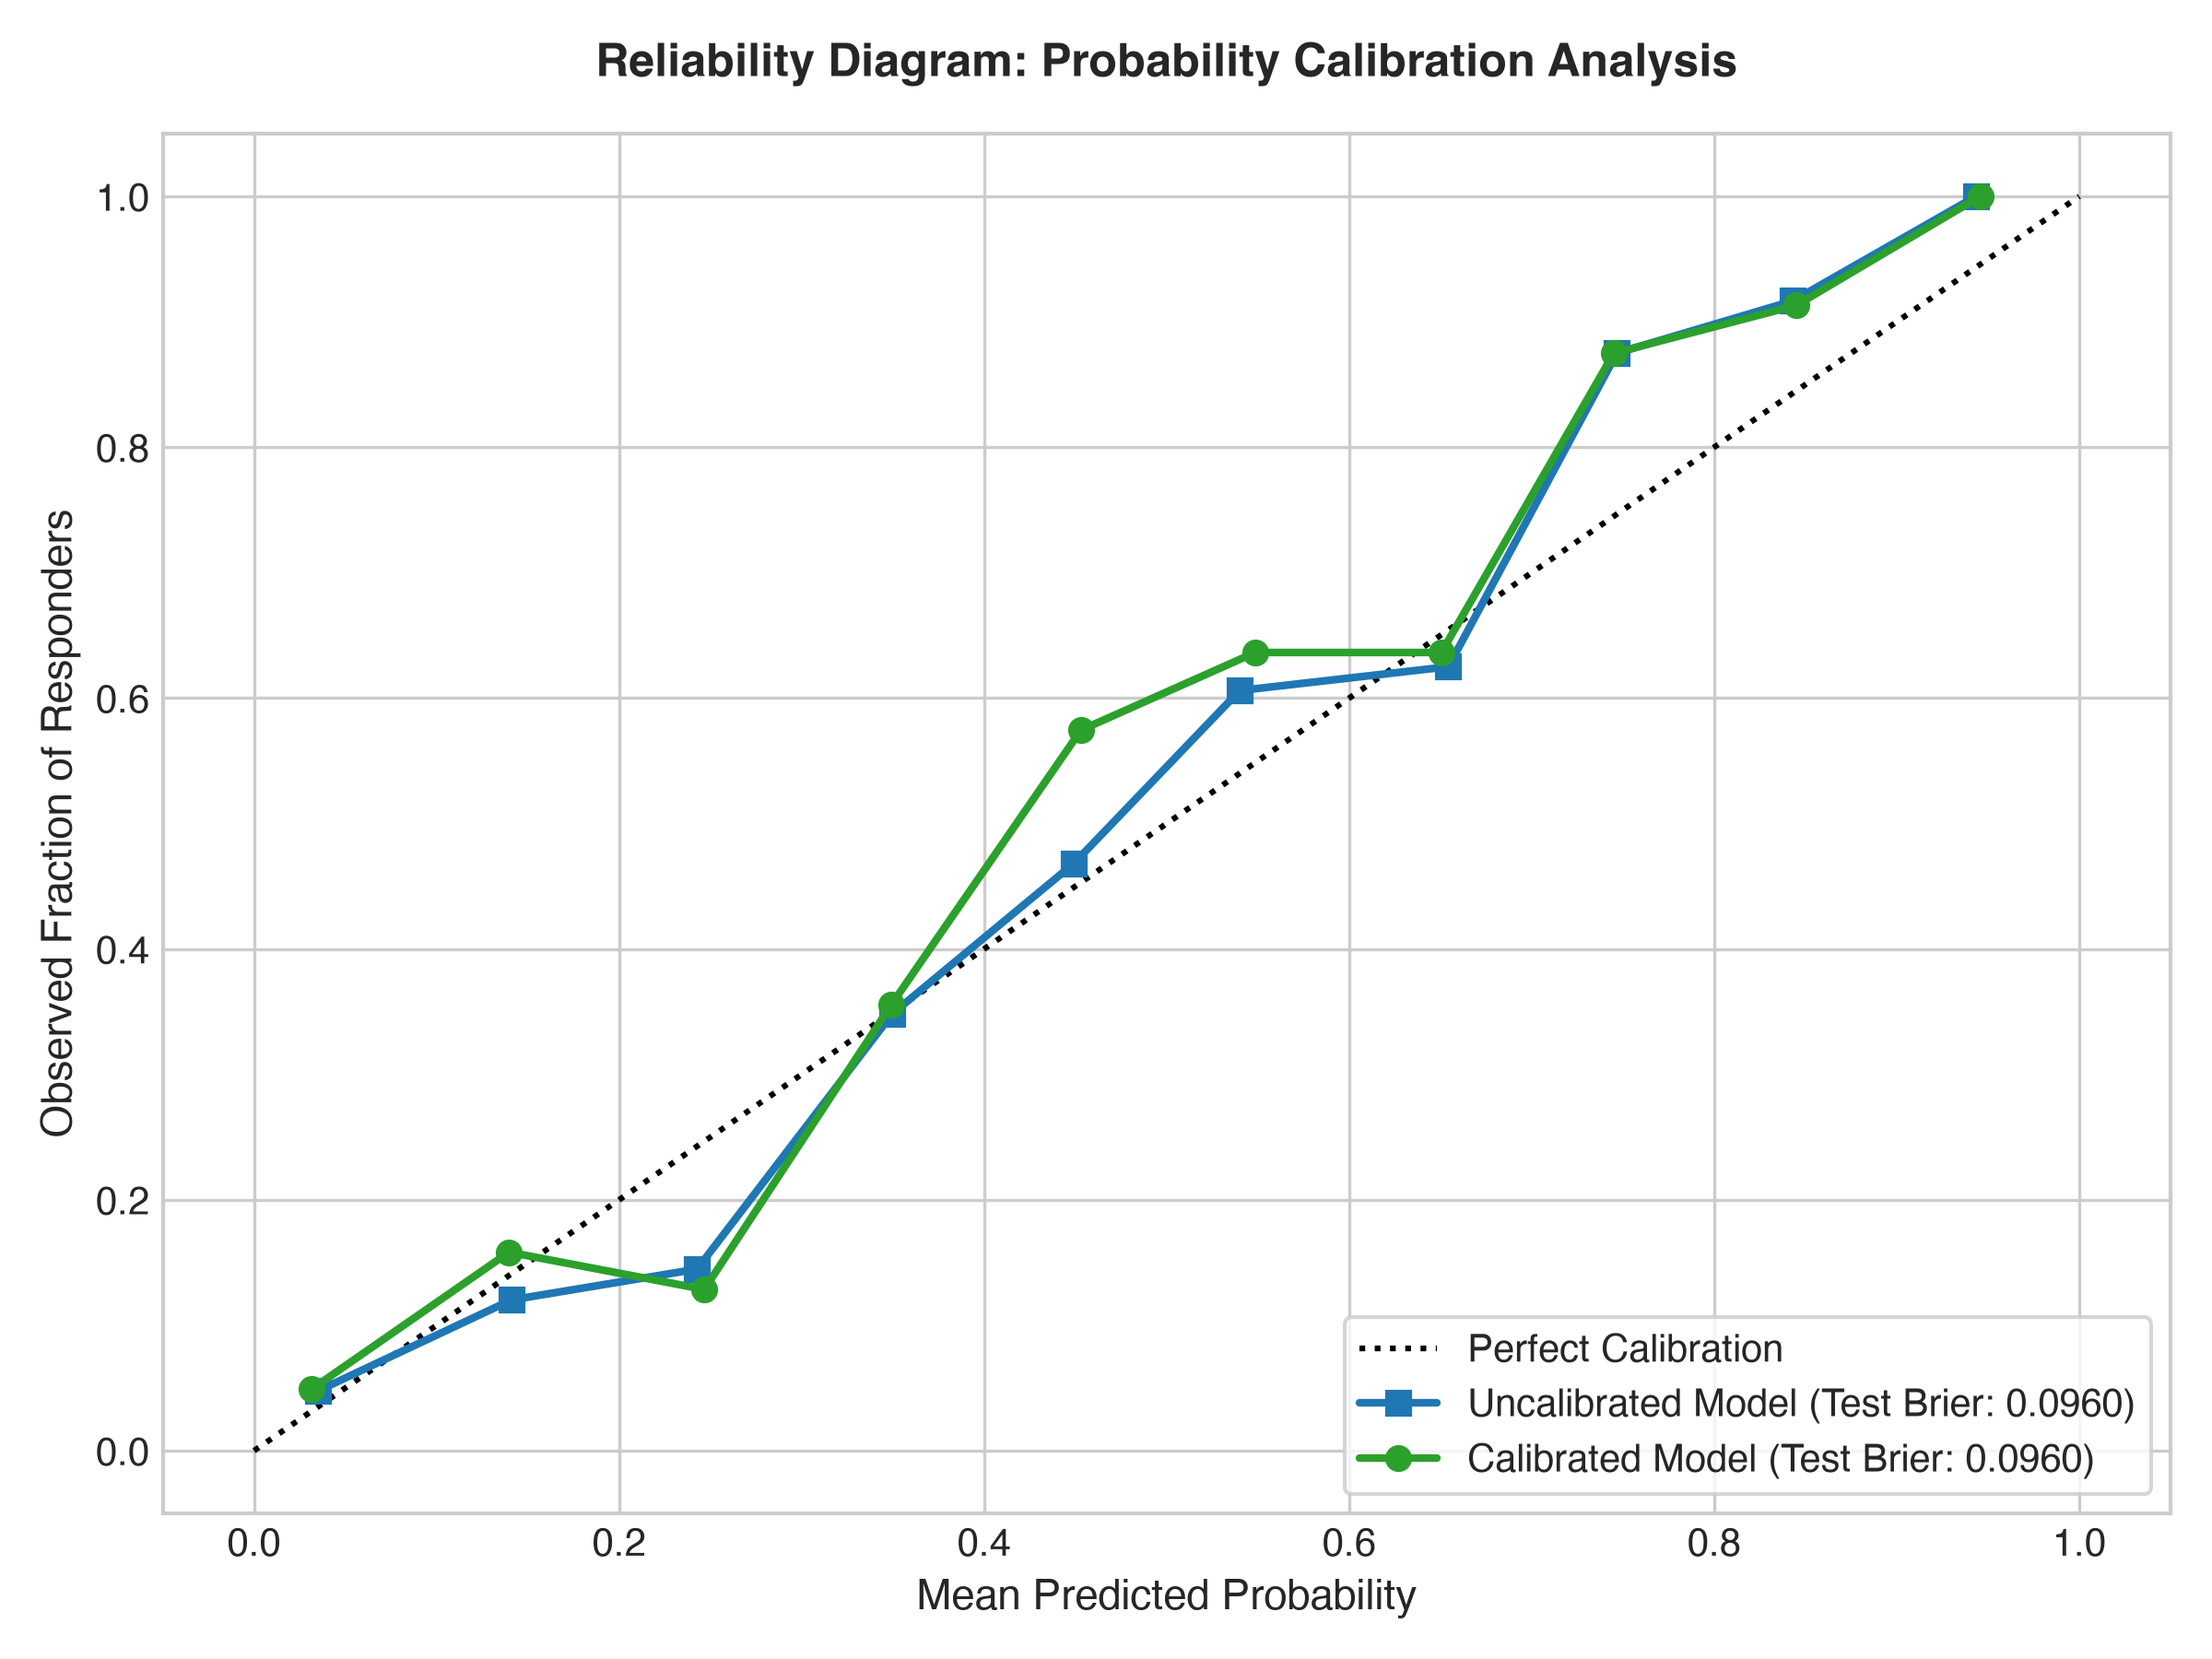

In [16]:
display(Image(filename=os.path.join(fig_dir, "calibration_curve.png"), width=600))

## 9. Explainability & Customer Persona Profiling
We analyze feature importance through Tree MDI, Permutation Importance, Odds Ratios, and SHAP, and examine profiles for both actual and predicted responders.


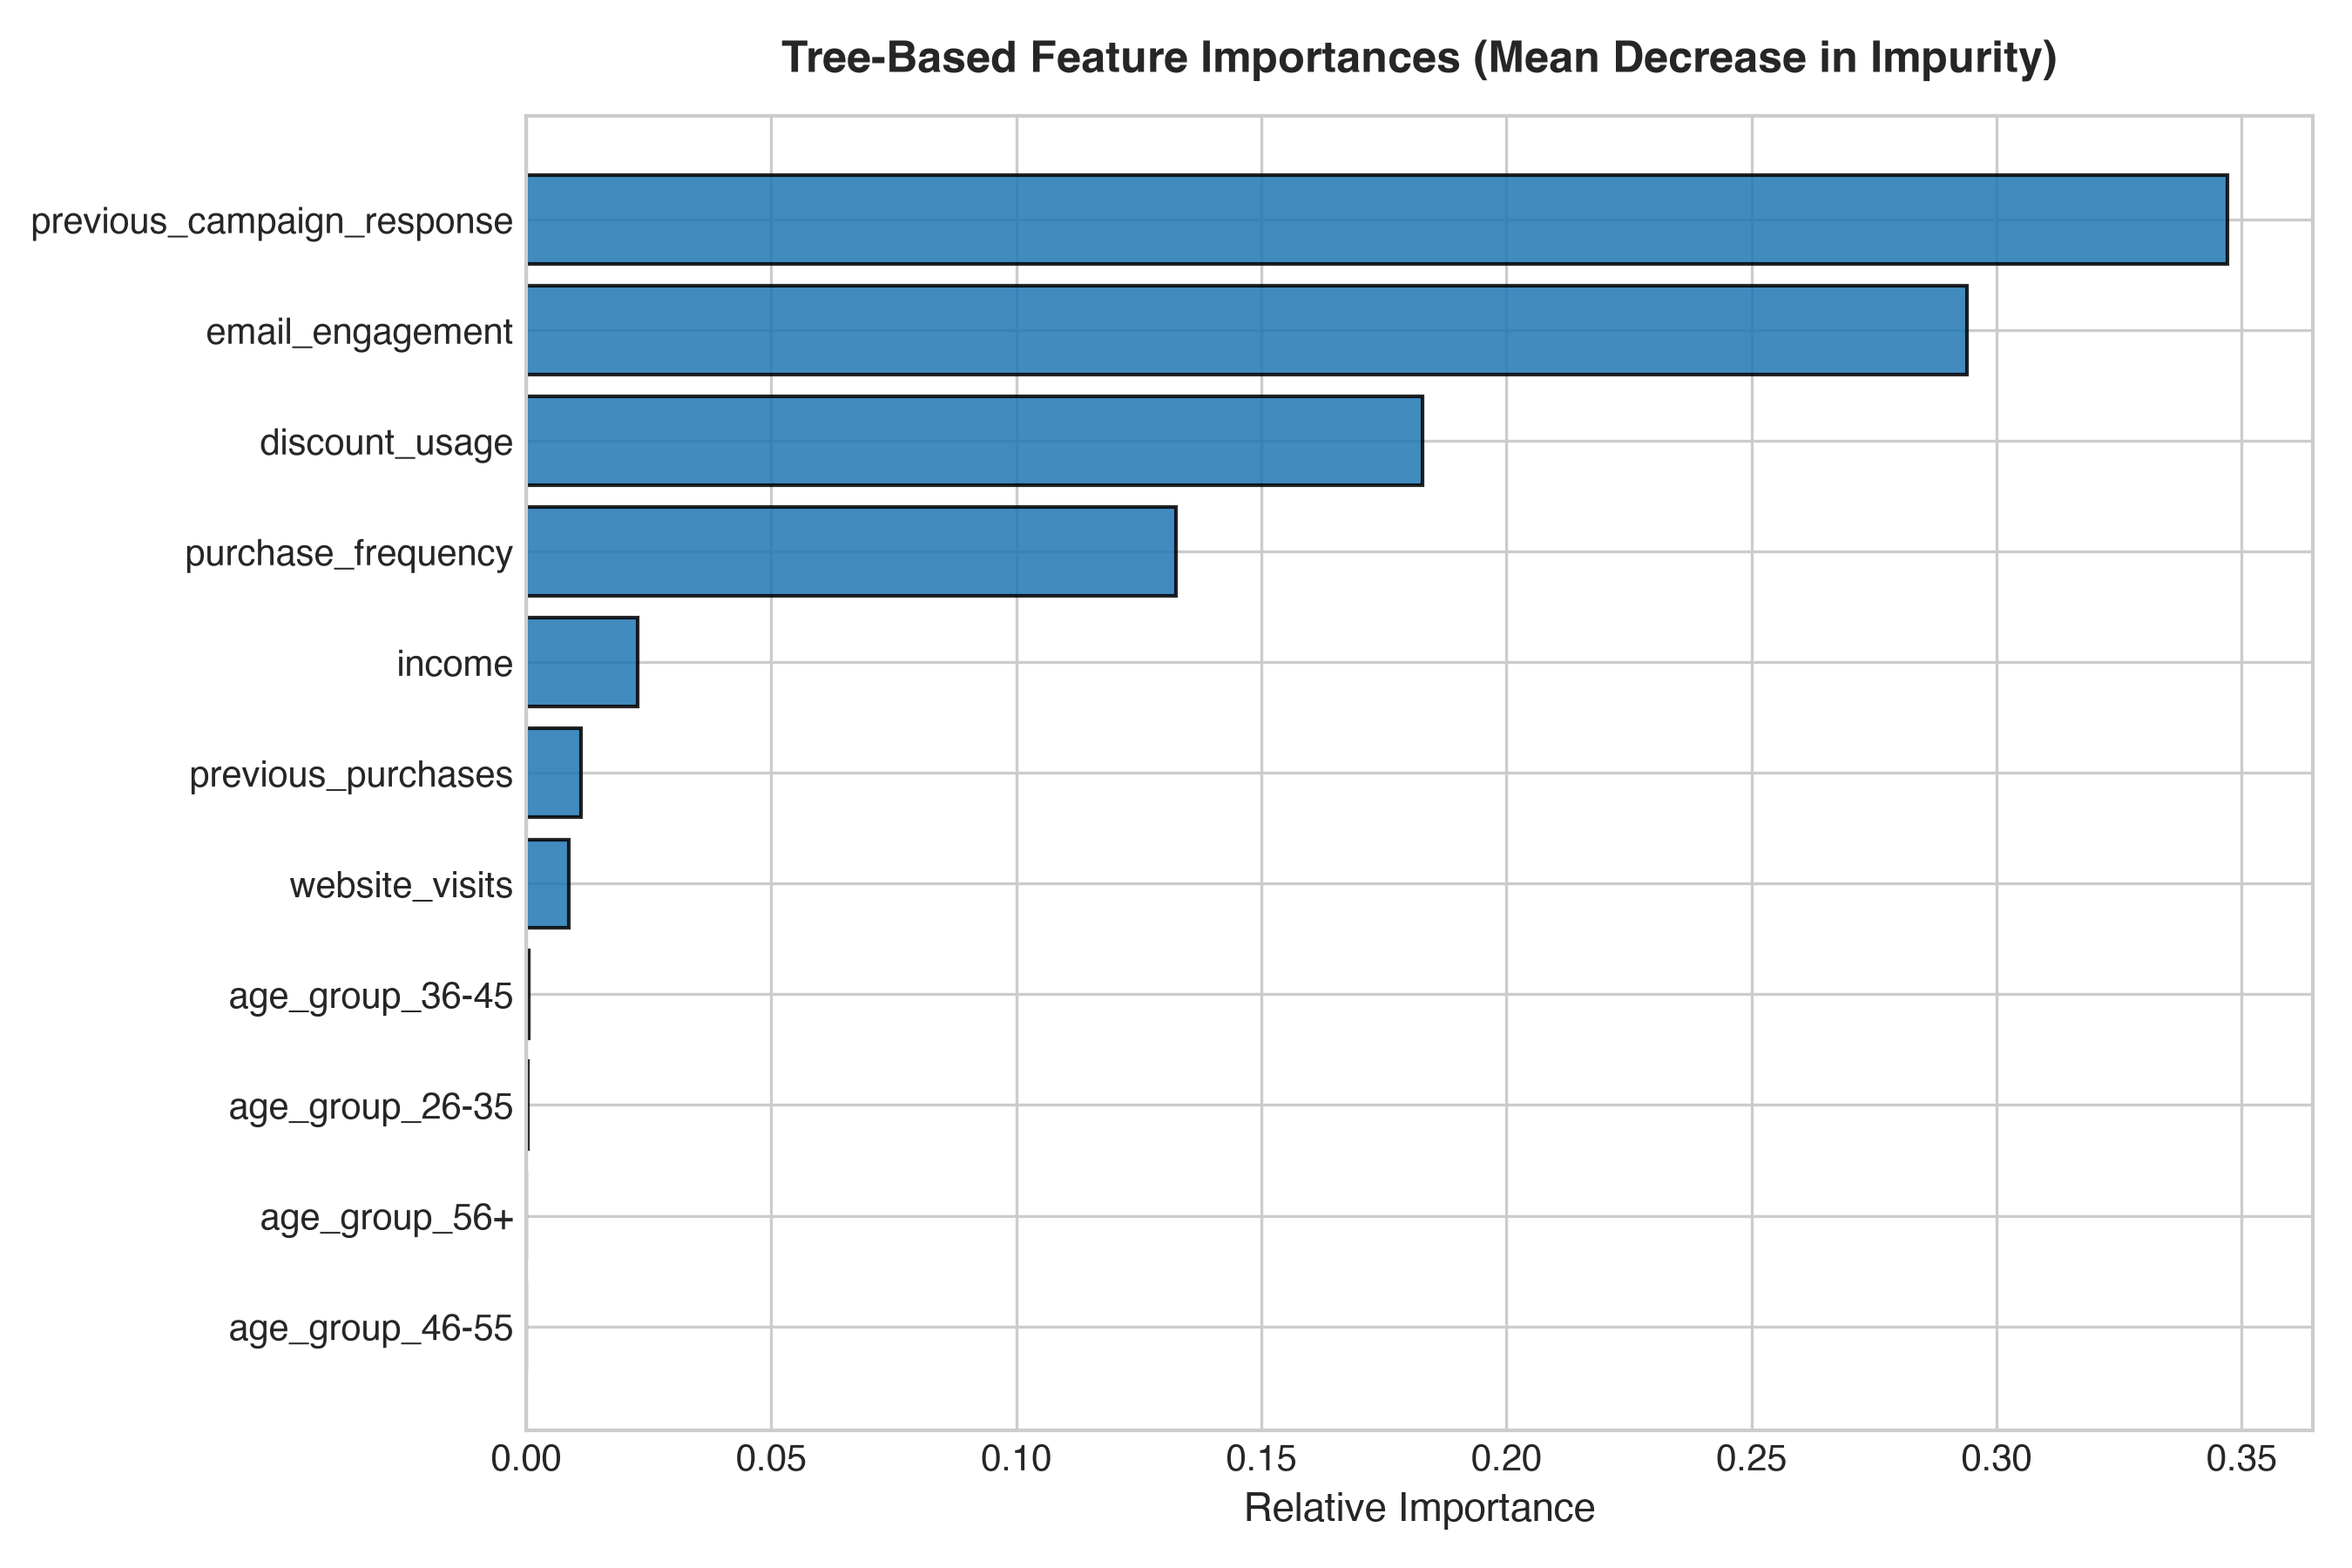

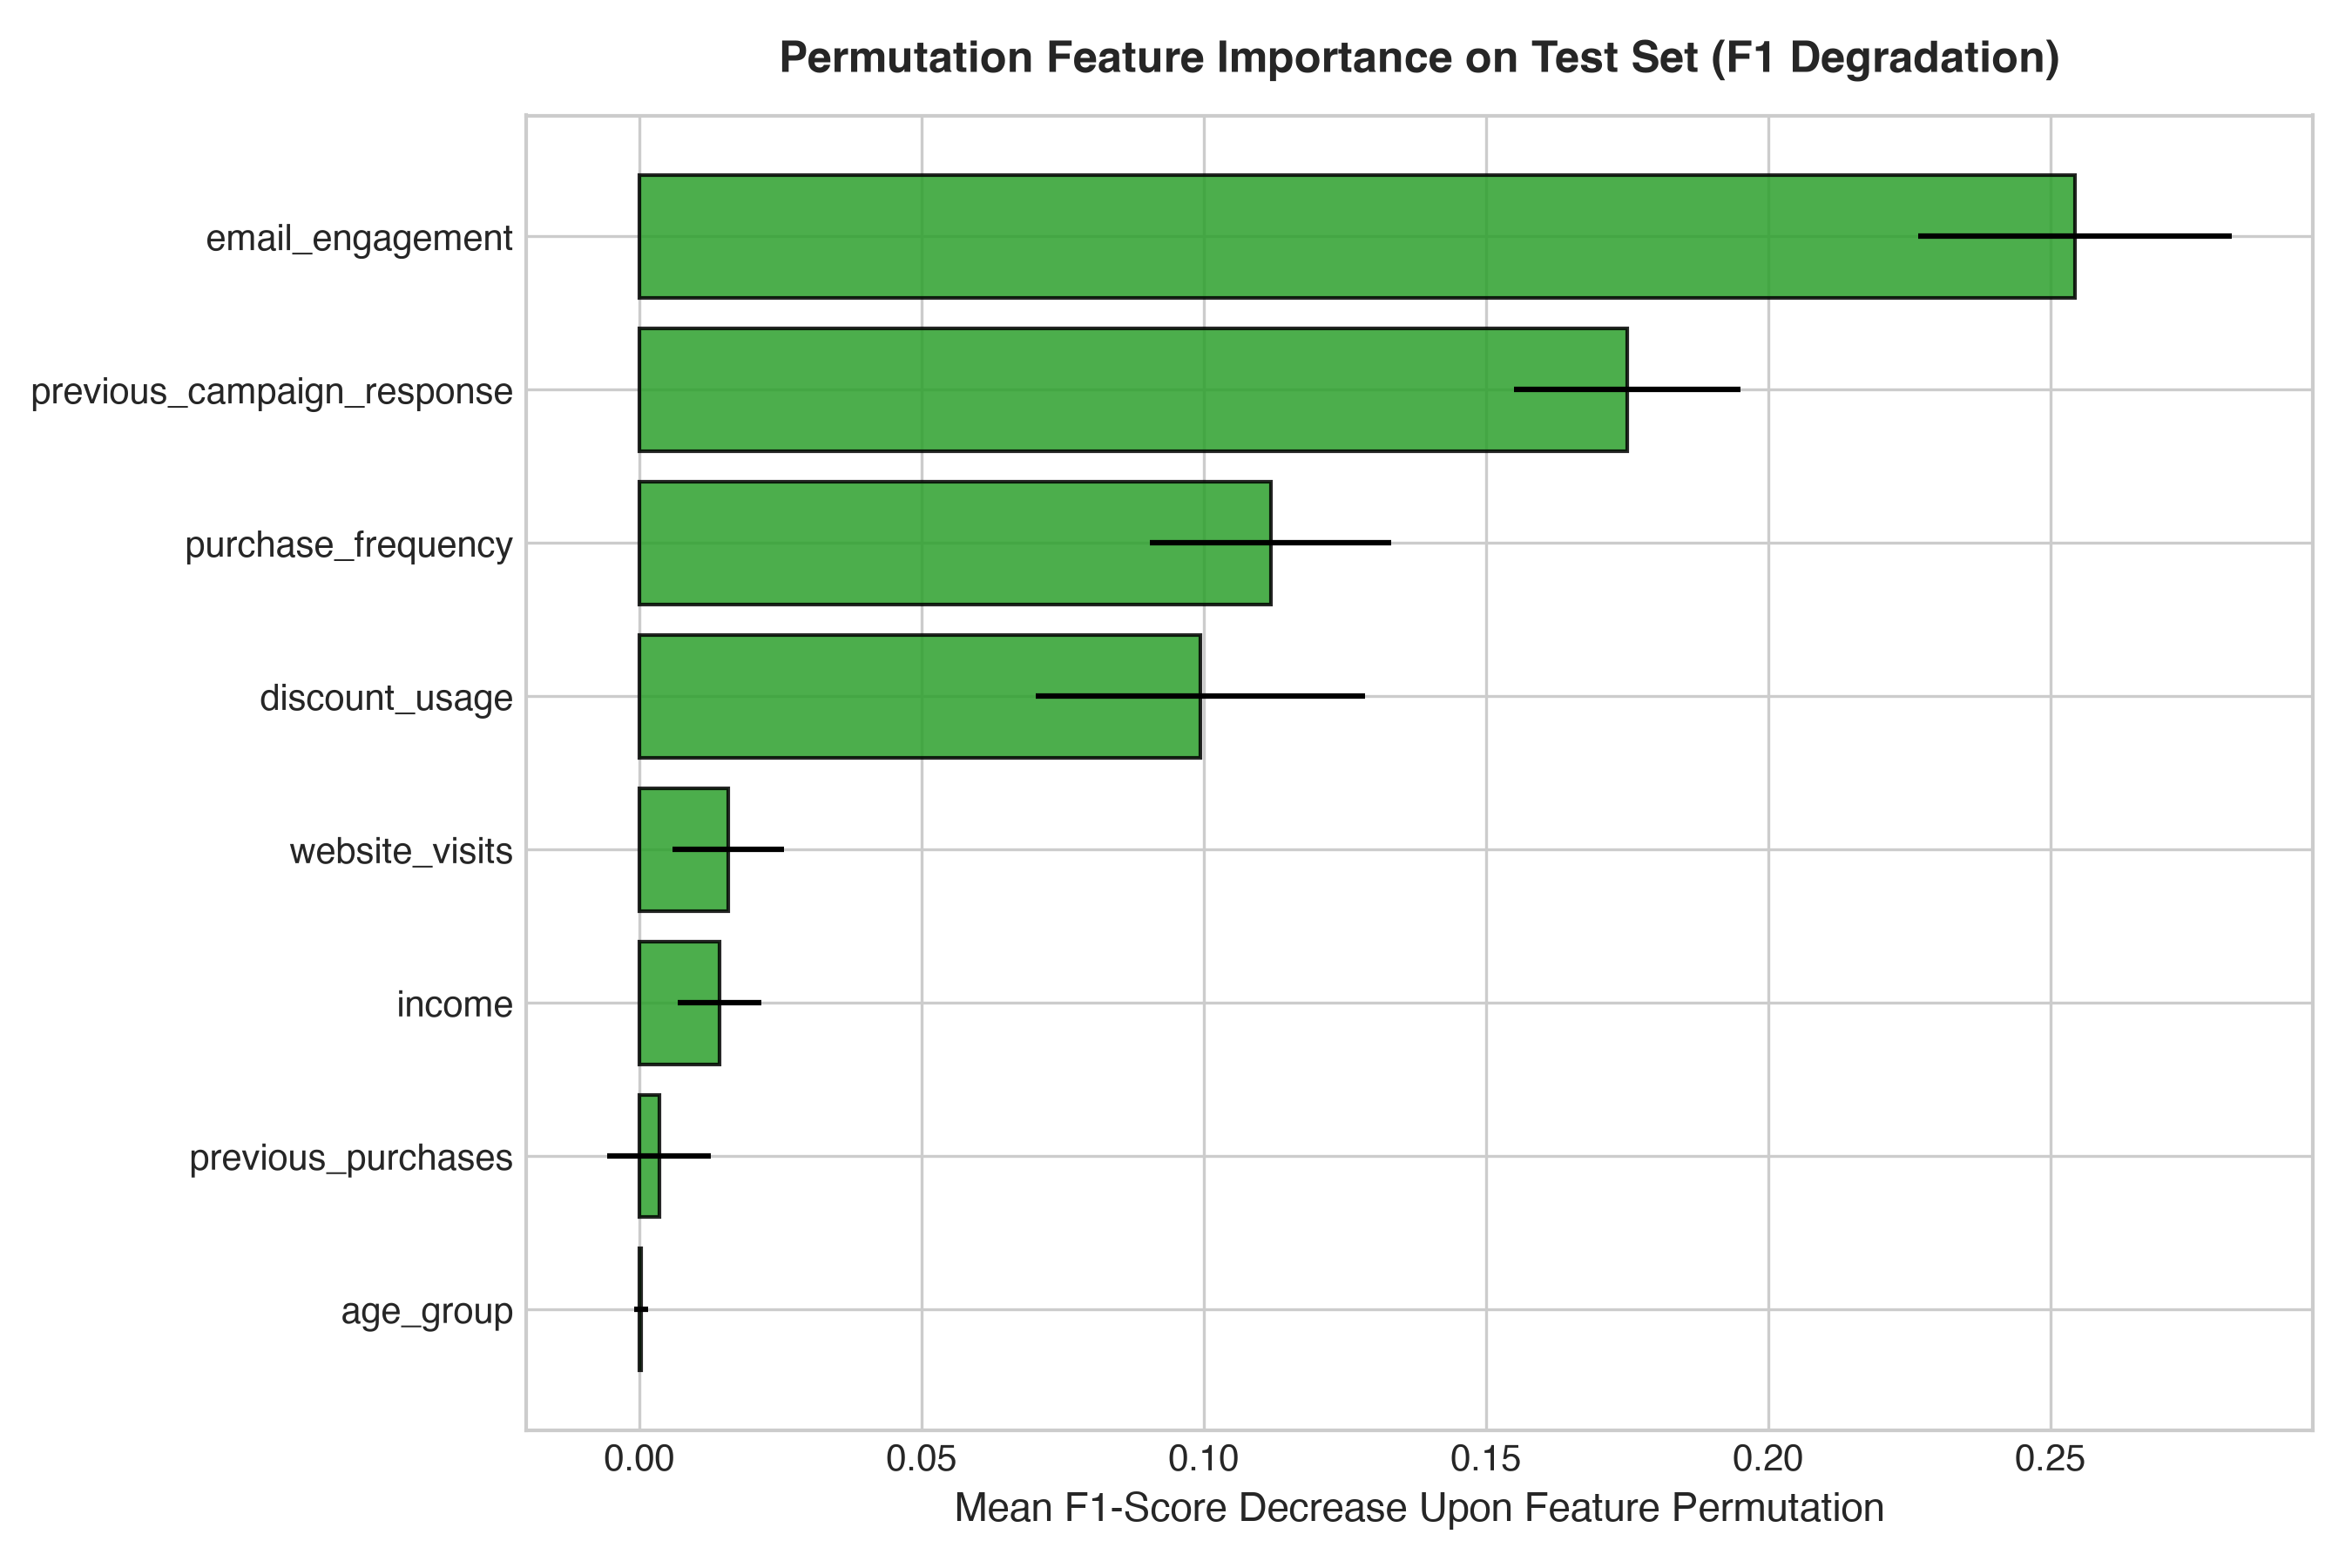

In [17]:
col_mdi = Image(filename=os.path.join(fig_dir, "feature_importance_tree.png"), width=450)
col_perm = Image(filename=os.path.join(fig_dir, "feature_importance_permutation.png"), width=450)
display(col_mdi, col_perm)


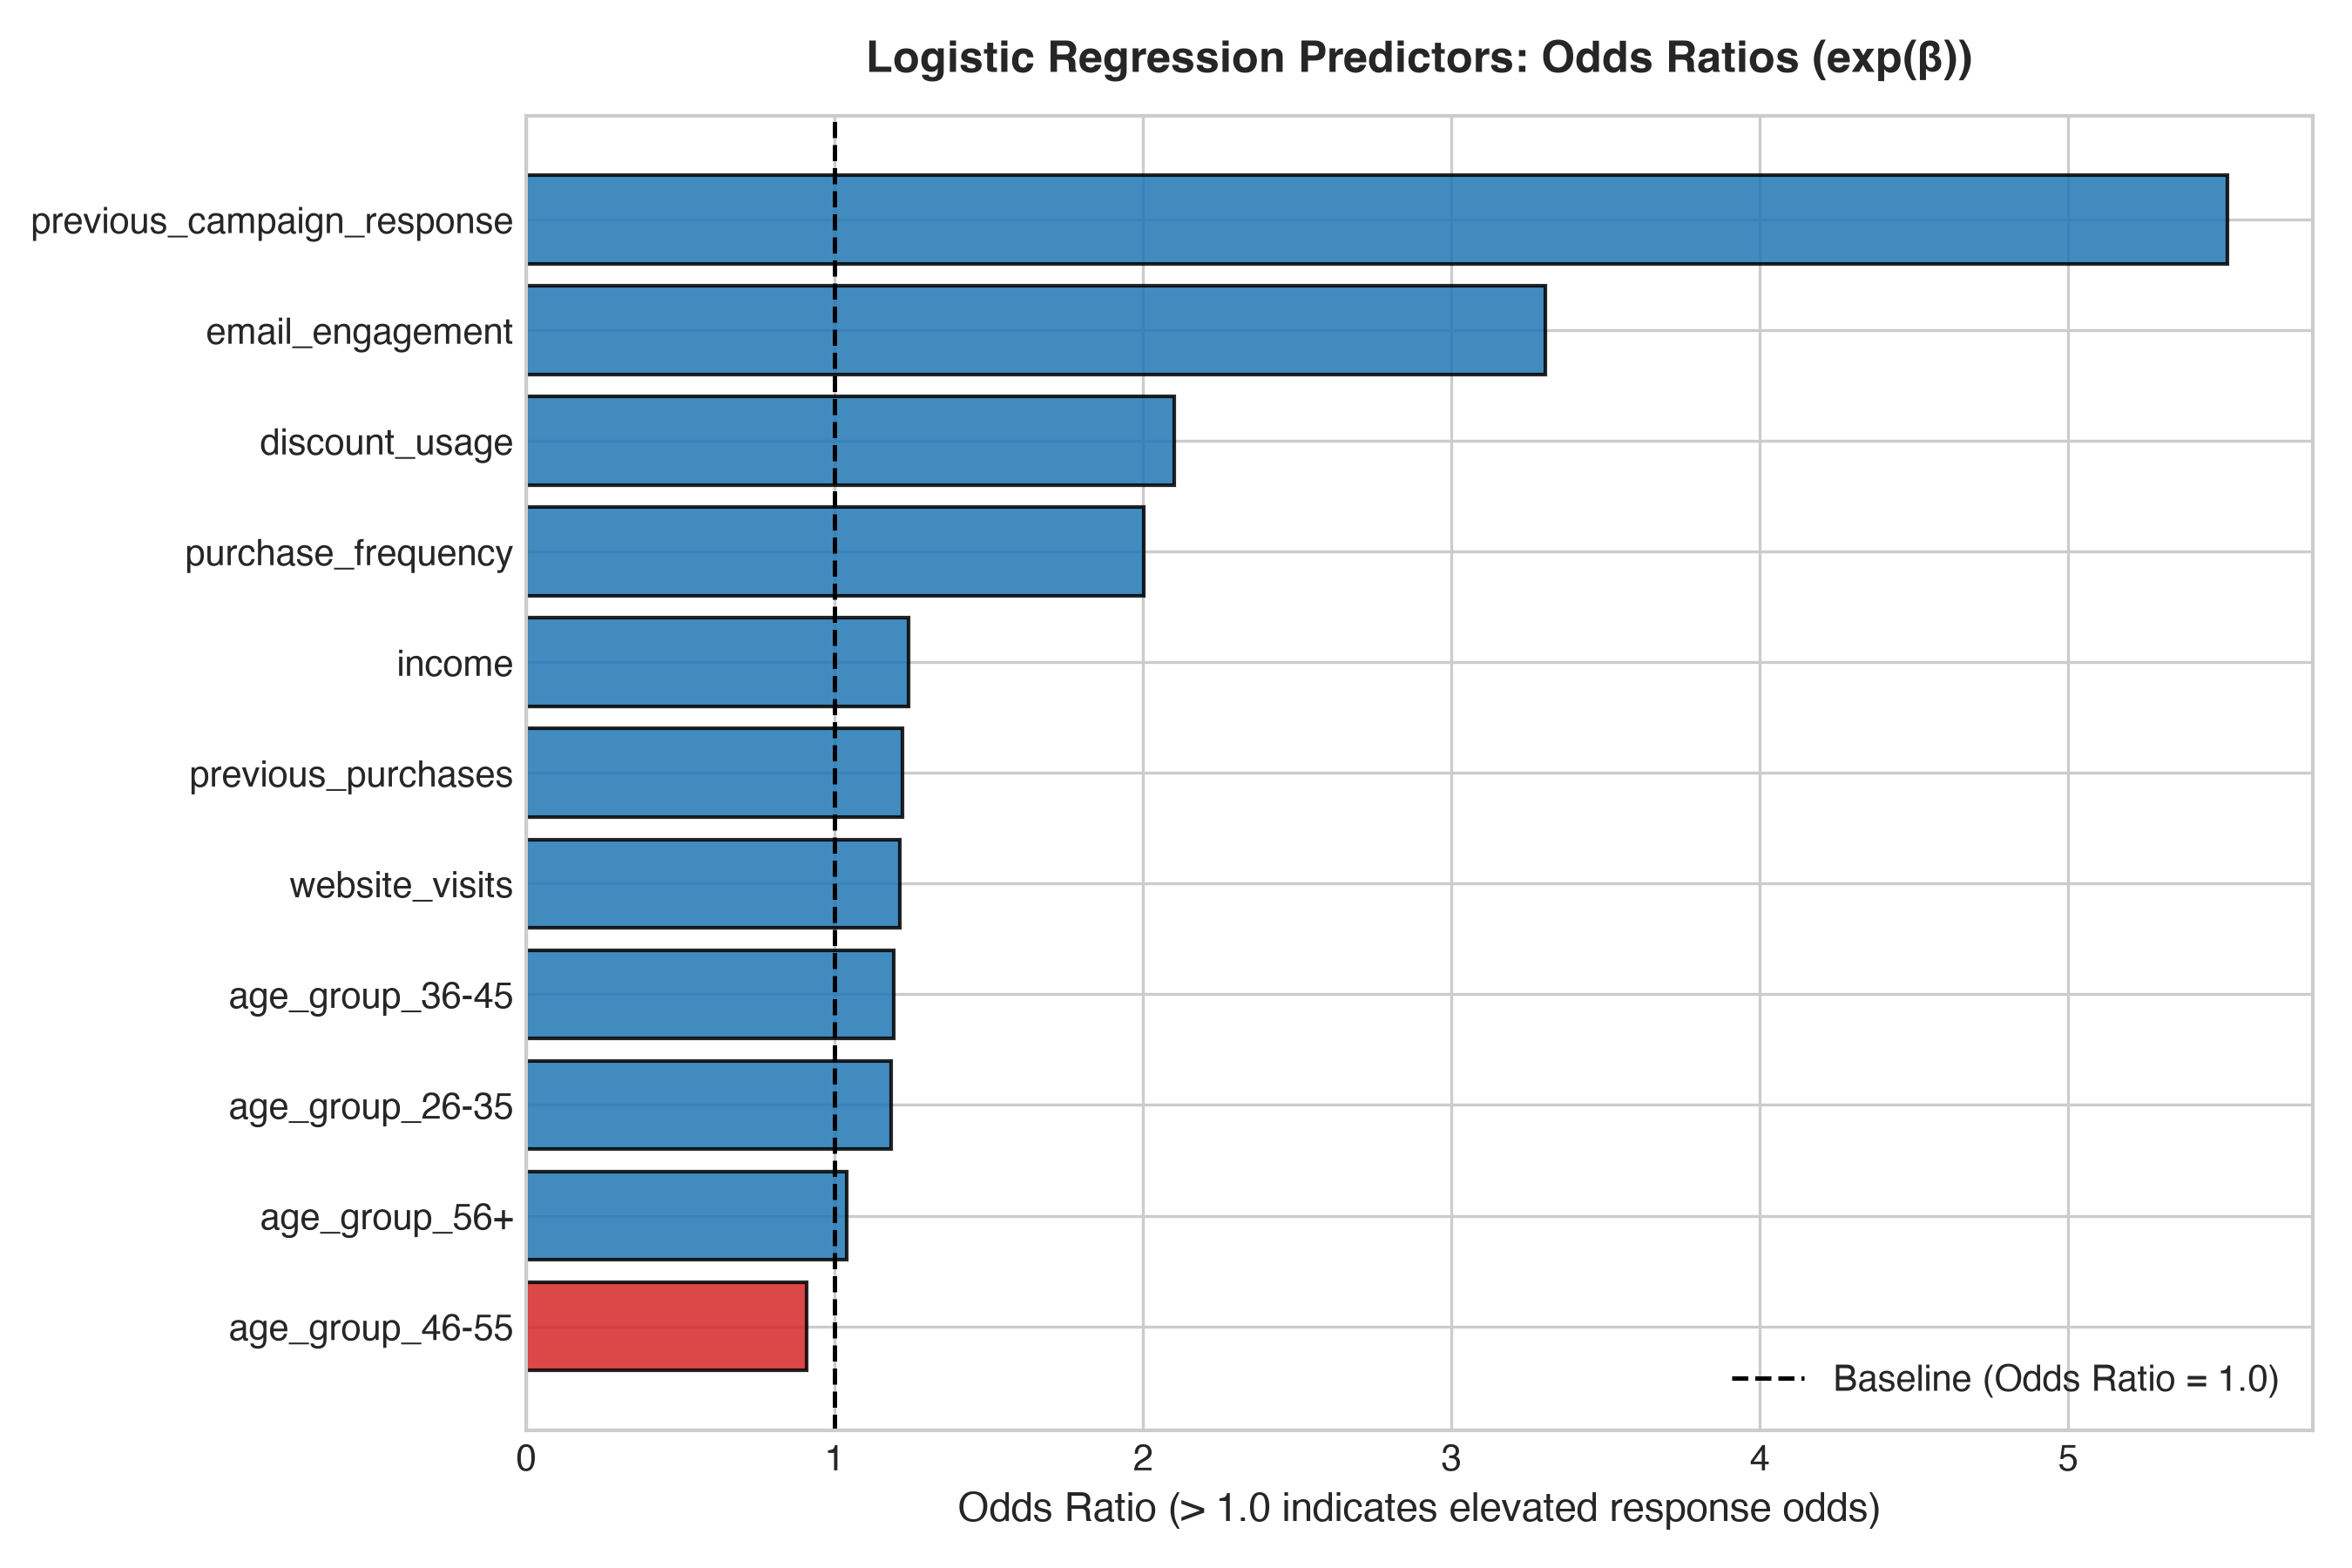

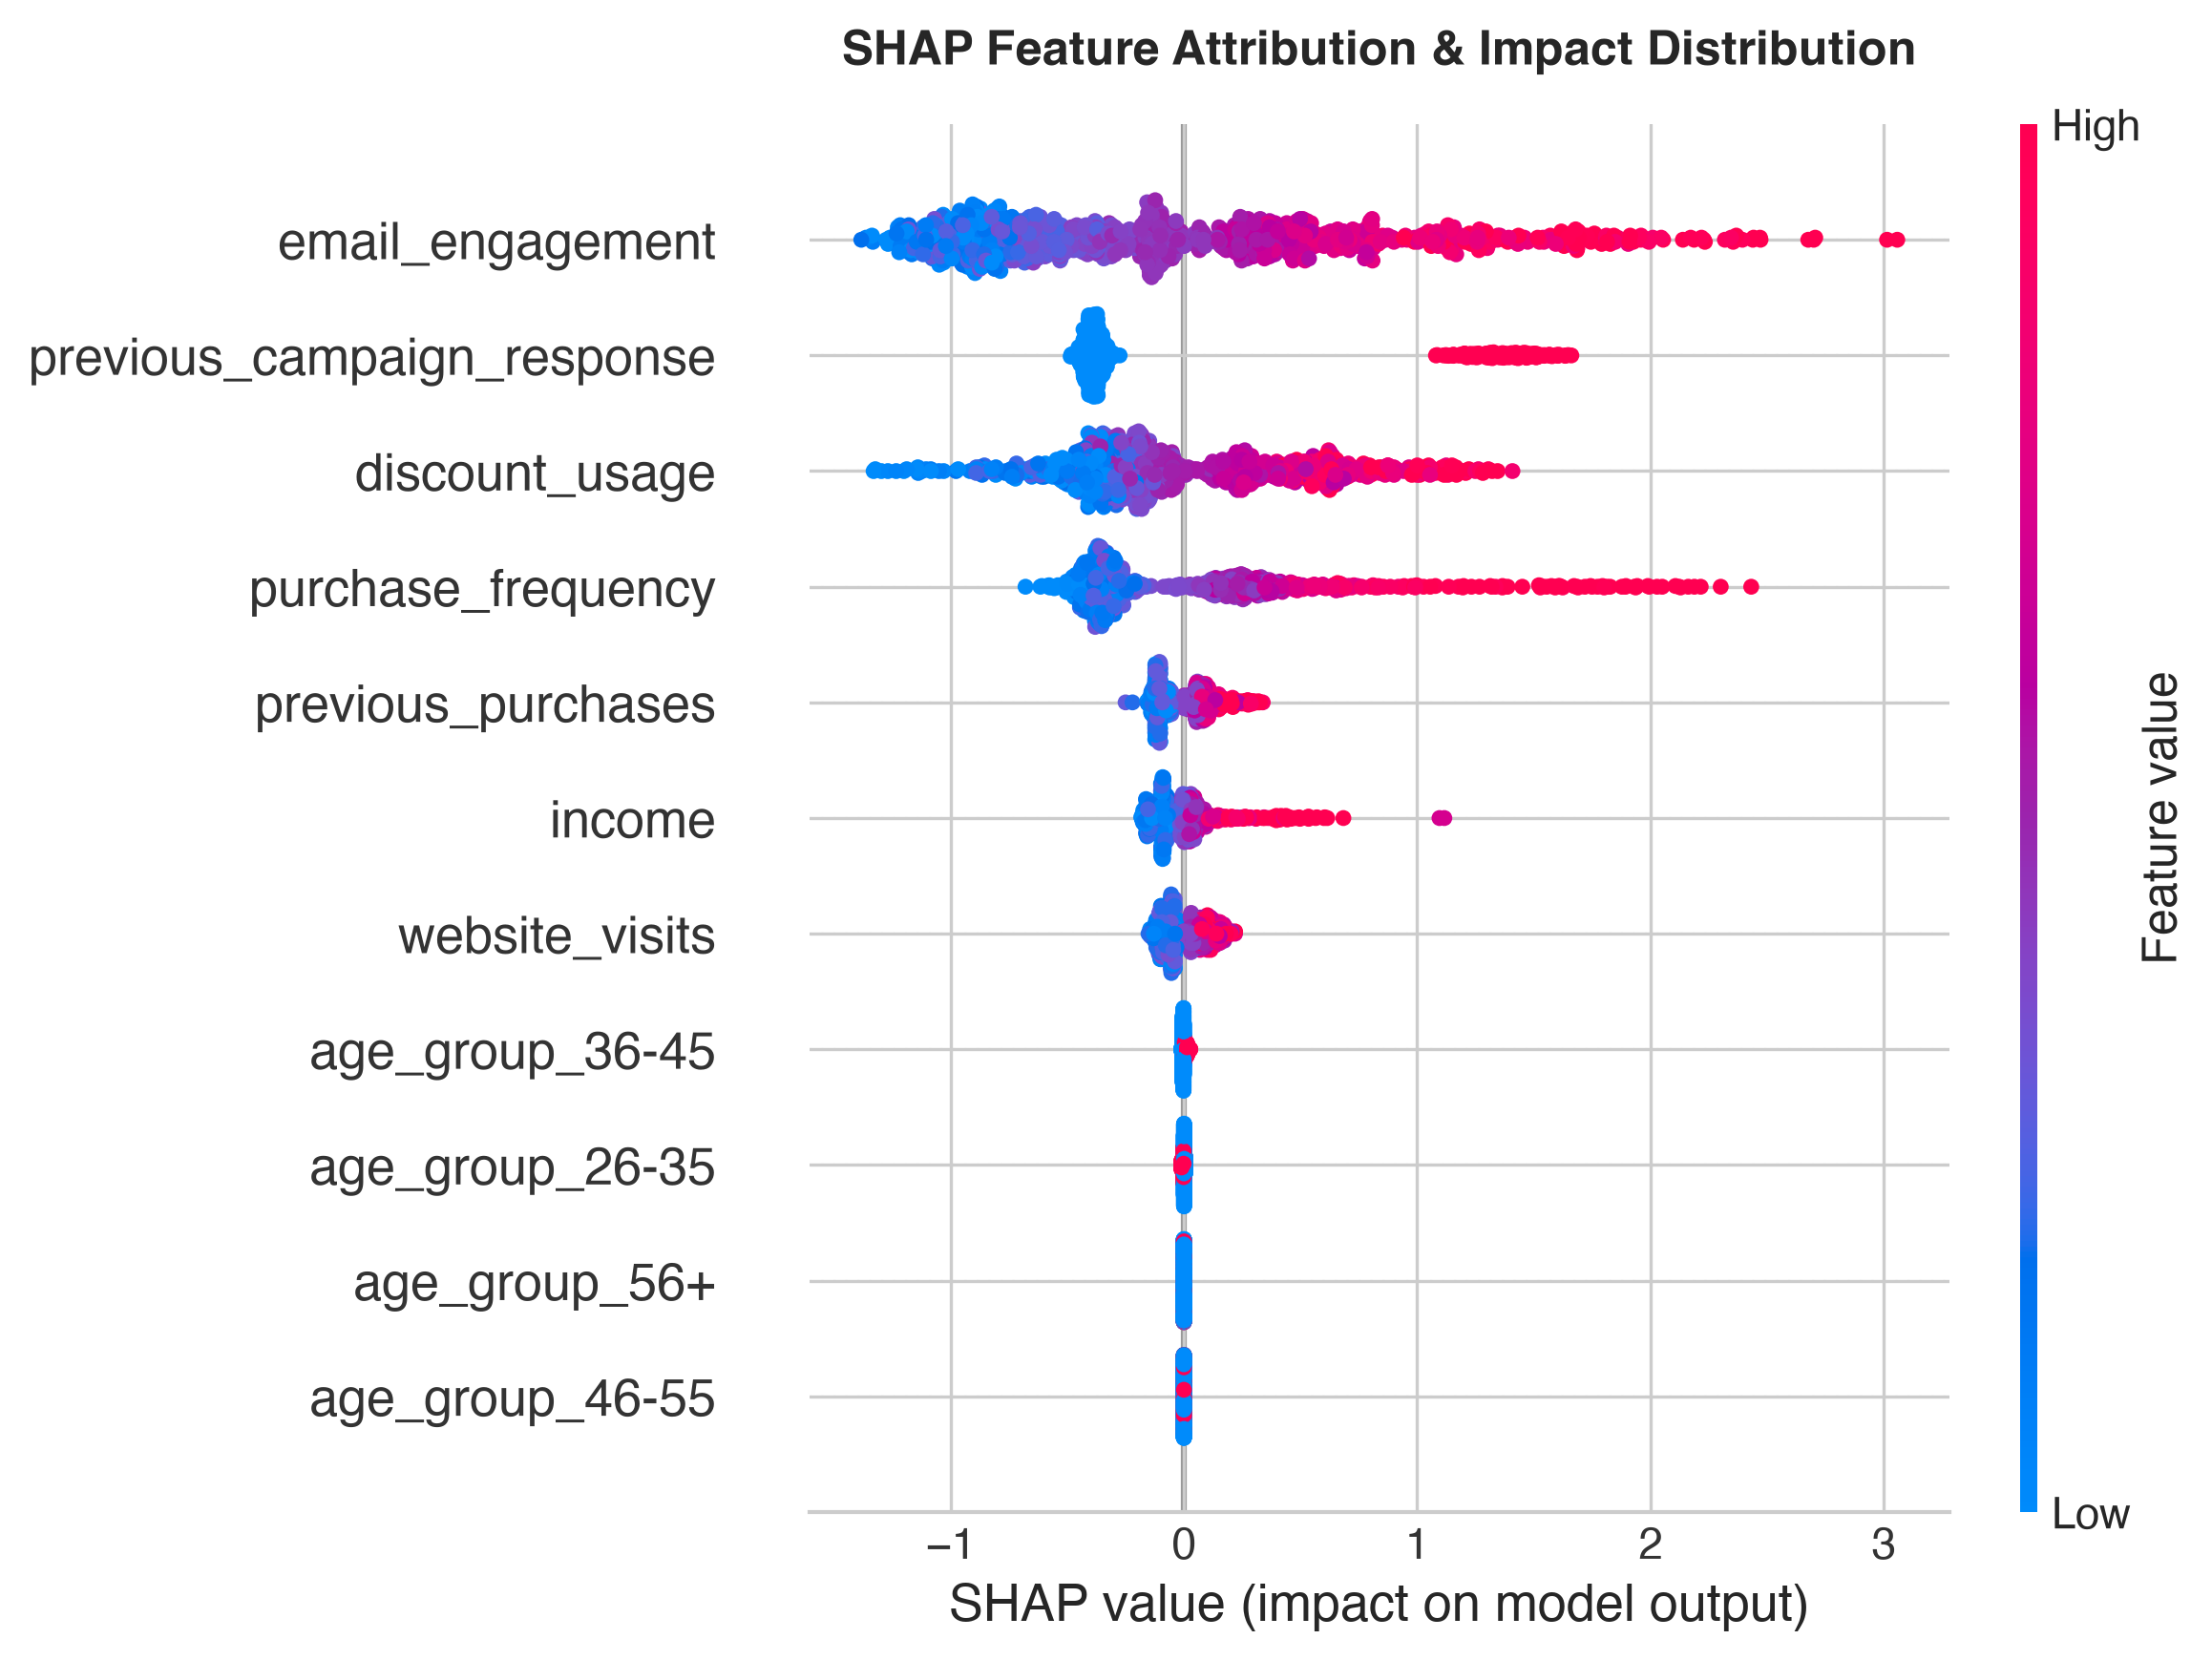

In [18]:
col_or = Image(filename=os.path.join(fig_dir, "feature_importance_odds_ratios.png"), width=450)
shap_path = os.path.join(fig_dir, "shap_summary.png")
if os.path.exists(shap_path):
    col_shap = Image(filename=shap_path, width=450)
    display(col_or, col_shap)
else:
    display(col_or)


In [19]:
prof_csv = os.path.join(PROJECT_ROOT, "reports", "customer_profiles.csv")
prof_df = pd.read_csv(prof_csv, header=[0, 1], index_col=0)
print("=== Customer Persona Profiles: Actual vs Predicted Responders ===")
display(prof_df)


=== Customer Persona Profiles: Actual vs Predicted Responders ===


income           previous_purchases         \
                             mean    median               mean median   
Actual Non-Responder     54949.97  48154.96               7.14    7.0   
Actual Responder         54284.37  46254.18               7.39    7.0   
Predicted Non-Responder  51316.35  45023.34               6.63    6.0   
Predicted Responder      58283.62  50371.82               7.76    7.0   

                        purchase_frequency        previous_campaign_response  \
                                      mean median                       mean   
Actual Non-Responder                  1.85   1.63                       0.10   
Actual Responder                      2.67   2.38                       0.53   
Predicted Non-Responder               1.63   1.49                       0.01   
Predicted Responder                   2.39   2.20                       0.37   

                               website_visits        email_engagement         \
                        median           mean median             mean median   
Actual Non-Responder       0.0           8.77    7.0             0.37   0.35   
Actual Responder           1.0          10.68    9.0             0.56   0.57   
Predicted Non-Responder    0.0           8.48    7.0             0.28   0.27   
Predicted Responder        0.0           9.82    9.0             0.52   0.52   

                        discount_usage         
                                  mean median  
Actual Non-Responder              0.41   0.40  
Actual Responder                  0.49   0.50  
Predicted Non-Responder           0.37   0.36  
Predicted Responder               0.49   0.49

## 10. Direct Answers to the 6 Core Research Questions

### Question 1: Can campaign responses be predicted?
**Answer:** **Yes, with high statistical confidence.**  
The deployed model achieves a held-out test **ROC-AUC of 0.8759** (95% bootstrap CI: [0.8475, 0.9032]) and **PR-AUC of 0.7286** (95% bootstrap CI: [0.6723, 0.7858]). In gains analysis, the top 20% of scored customers capture **49.8%+ of all campaign responders**, demonstrating substantial predictive power over random targeting.

### Question 2: Which customer characteristics influence response?
**Answer:** **Past campaign response history and digital email engagement overwhelmingly dominate static demographics.**  
1. `previous_campaign_response` (Odds Ratio = **5.5174**): Customers who responded previously have >5.5x higher odds of responding again.
2. `email_engagement` (Odds Ratio = **3.3052**): Responders exhibit over 50% average email open/click engagement.
3. `discount_usage` and `purchase_frequency` (Odds Ratios ~2.0 - 2.1): Price sensitivity and velocity double response likelihood.
Static demographic attributes (`income` and `age_group`) exhibit minimal explanatory power compared to behavioral interaction metrics.

### Question 3: Which algorithm performs best?
**Answer:** **Logistic Regression (Calibrated).**  
Across 5-fold cross-validation, Logistic Regression achieved a CV PR-AUC of **0.7223 ± 0.0267** and CV ROC-AUC of **0.8883 ± 0.0104**. While Gradient Boosting performed similarly (CV PR-AUC: 0.7169 ± 0.0254), both models are within 1 standard deviation and statistically tied. Logistic Regression broke the tie decisively by delivering a lower False Positive Rate at 70% recall (**0.1026 vs 0.1214**), along with superior operational interpretability and microsecond inference latency.

### Question 4: Can ML reduce unnecessary marketing expenditure?
**Answer:** **Yes, by 46.6% to 76.6%.**  
In the 1,000-customer test cohort:
- Mass outreach costs **$5,000.00** with 799 wasted contacts, yielding **$5,050.00** in net profit.
- F1-Optimal targeting costs **$1,170.00**, saving **$3,830.00 (76.6% cost reduction)**.
- Profit-Optimal targeting costs **$2,670.00**, saving **$2,330.00 (46.6% cost reduction)** while maximizing total profit.

### Question 5: How can false positives be reduced?
**Answer:** **Through threshold optimization and calibrated risk scoring.**  
Operating at the default 0.50 threshold restricts False Positives to only 27 (3.4% of total negatives), but misses 101 responders. By calibrating probabilities and tuning the decision threshold via OOF cross-validation, marketing managers can precisely calibrate the False Positive Rate to their organization's tolerance and working capital limits.

### Question 6: Can the model identify potential campaign responders?
**Answer:** **Yes, capturing up to 91.0% of responders while contacting only 53.4% of the population.**  
At the Profit-Optimal threshold ($t = 0.07$), the model captures **183 out of 201 actual responders**, yielding **$6,480.00 net profit** and an ROI of **242.7%**.

---

## 11. Honest Limitations & Risk Disclosures
1. **Synthetic Data Generation:** Dataset was generated with seed 42 to model realistic consumer patterns. Real-world retail environments introduce unobserved confounders (seasonality, ad fatigue, competitor promotions).
2. **Propensity vs Causal Uplift:** The model estimates *response propensity* ($P(Y=1|X, T=1)$), not *causal uplift* (incremental buyers). Randomized A/B control testing is required to isolate true incremental uplift.
3. **Sample Size & Test Set Variance:** The held-out test set comprises 1,000 customers (201 positive events). The 95% bootstrap confidence intervals for test ROC-AUC ([0.8475, 0.9032]) and PR-AUC ([0.6723, 0.7858]) reflect this variance.
